<a href="https://colab.research.google.com/github/kmkarakaya/btk_rag_bot_egitimi/blob/main/6_Vekt%C3%B6r_Veritaban%C4%B1n%C4%B1_Olu%C5%9Fturmak_Metin_Eri%C5%9Fimi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6. Vektör Veritabanını Oluşturmak ve Metin Erişimi

## Copyright 2025 Murat Karakaya

## 🚪Giriş ve Genel Bakış



Bu bölümde, **Erişim Destekli Metin Üretimi (RAG)** mimarisinin kalbinde yer alan **vektör tabanlı bilgi erişim süreci** adım adım ele alınacaktır. Amaç, bir bilgi tabanının yalnızca metin içeriklerinden değil, bu içeriklerin anlamlı temsilinden oluştuğu fikrini kavratmak ve uygulamalı olarak bu sistemi inşa etmeyi öğretmektir.





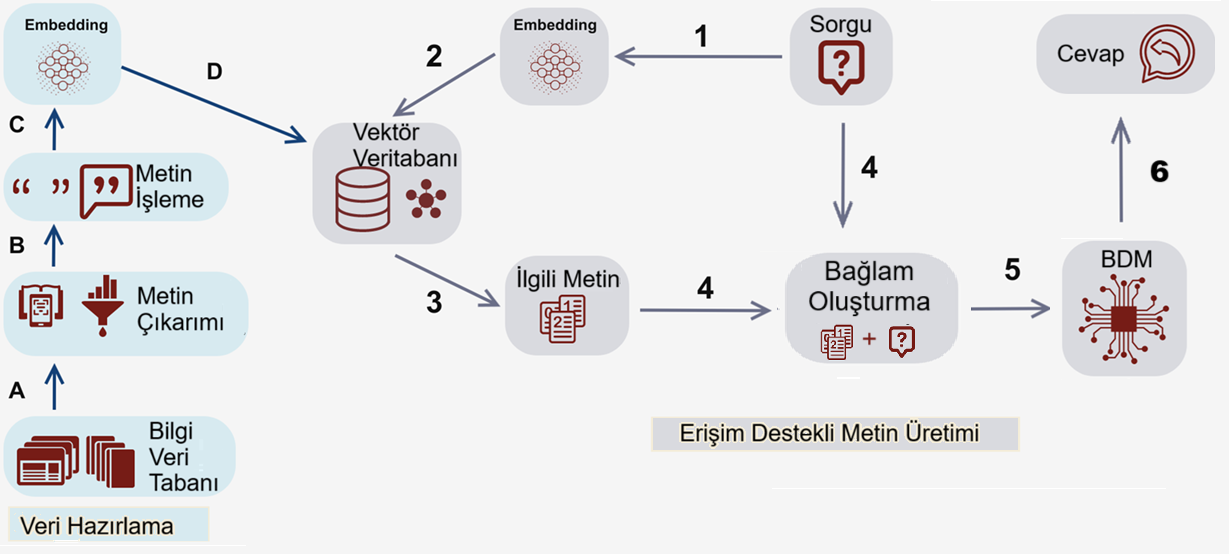

### 🎯 Neler Öğreneceğiz?
- 📄 **Ham belgelerden (PDF vb.) yapılandırılmış metin çıkarımının** nasıl yapılacağını,  
- ✂️ Bu metinlerin **anlam bütünlüğünü koruyarak parçalara (chunk’lara)** nasıl ayrıldığını,  
- 🔢 Her bir parçanın, **gömme (embedding)** yöntemiyle **sayısal vektör temsillere** nasıl dönüştürüldüğünü,  
- 🧠 Bu vektörlerin, **ChromaDB gibi özel bir vektör veritabanına** nasıl kaydedildiğini,  
- 💬 **Kullanıcıdan gelen doğal dil sorgularının** nasıl vektöre dönüştürülüp, veritabanında **anlamsal benzerlik esasına göre eşleştirildiğini**,  
- 📌 Ve bu işlem sonucunda, sistemin **bağlamsal olarak en uygun bilgi parçalarını nasıl geri çağırdığını**  
öğreneceklerdir.



### 🔍 Neden Önemli?

Bu süreç, RAG sistemlerinin **"üretmeden önce eriş"** felsefesinin temelini oluşturur. Dil modeli, yalnızca kendi parametrik bilgisini değil, erişilen bu bilgi parçalarını da kullanarak daha **doğru, kaynakla destekli ve bağlama uygun yanıtlar** üretir.

📌 Bu bölümdeki uygulamalar, bir sonraki adımda:

- Büyük dil modeli ile **RAG tabanlı sohbet botu** geliştirme,
- Geri çağrılan bilgilerin **sisteme nasıl enjekte edileceği**,
- Ve **halüsinasyonları azaltan bilgi kontrollü üretim süreçlerinin** nasıl çalıştığı

gibi konular için sağlam bir teknik altyapı oluşturacaktır.



> 💡 **Unutmayın:**  
> RAG sistemlerinde yanıtın kalitesi, sadece modelin gücüne değil; erişilen bilginin doğruluğu, temsil biçimi ve zamanında geri çağrılmasına da bağlıdır.


## 📚Bilgi Tabanı (Knowledge Base)


Erişim Destekli Metin Üretimi (RAG) sisteminin temel dayanağı, büyük dil modellerinin eğitildiği bilgi sınırlarını aşmak için **dış bilgi kaynaklarının** sisteme entegre edilmesidir. Bu sistemde model, sadece kendi belleğinde var olan bilgilerle değil, harici bilgi kaynaklarından erişilen içeriklerle zenginleştirilmiş bir bağlam üzerinden yanıt üretir.

Bu yaklaşımın ilk ve en kritik adımı, **doğru ve güvenilir** bilgi kaynaklarının belirlenmesi ve bu kaynakların anlamlı ve erişilebilir bir biçime dönüştürülmesidir. İşte bu adımda Bilgi Tabanı (Knowledge Base) devreye girer.

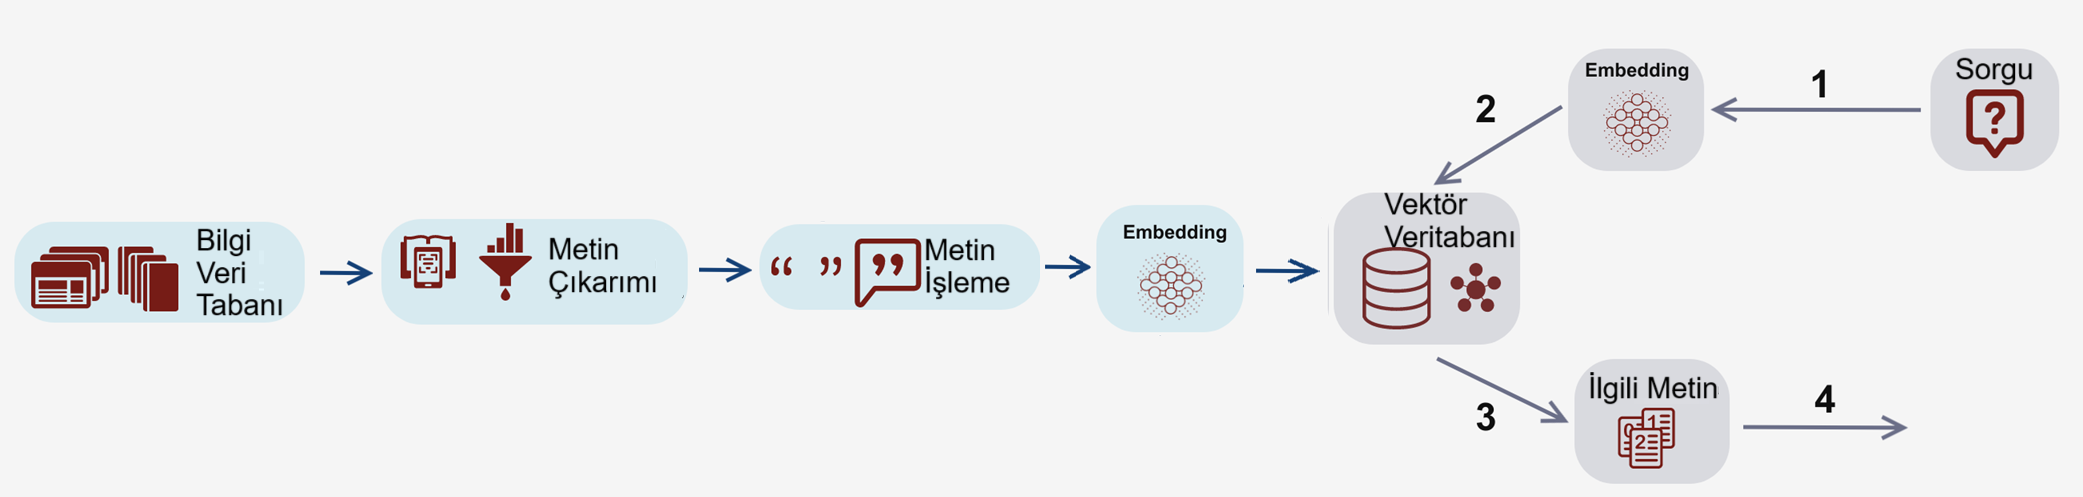

### Örnek Uygulama: TED Üniversitesi Eğitim Yönetmelik ve Yönergeleri
Bu eğitim kapsamında, RAG sistemini gerçek dünyaya uyarlamak için TED Üniversitesi tarafından yayımlanan [Eğitim Yönetmelik ve Yönergeleri](https://www.tedu.edu.tr/egitim-yonetmelik-ve-yonergeleri) kullanılacaktır.

Bu belgeler, aşağıdaki senaryolarda kullanılmak üzere bilgi tabanına dahil edilir:

📌 Senaryo 1 – Akademik Danışman Chatbotu:

>Öğrenci, sisteme şu soruyu yöneltir:
“Çift anadal programına başvuru koşulları nedir?”

Sistem, bu sorguyu alır, gömme (embedding) işleminden geçirir ve önceden bilgi tabanına alınmış “Çift Anadal Yönergesi” içindeki ilgili paragrafları vektör veritabanından getirir. Elde edilen içerik, LLM'e bağlam olarak sunularak yönetmeliğe dayalı, doğru ve açıklayıcı bir yanıt üretilir.

📌 Senaryo 2 – Ders Geçme Koşulları:

>“Bir dersi FF ile geçersem, yaz okulunda tekrar alabilir miyim?”

Bu durumda sistem, “Lisans Eğitim-Öğretim ve Sınav Yönetmeliği” içeriğinden ders tekrarı ve yaz okulu konularını içeren bölümleri getirir. Böylece yanıt, yönetmeliğe dayalı net bir bilgi sunar.

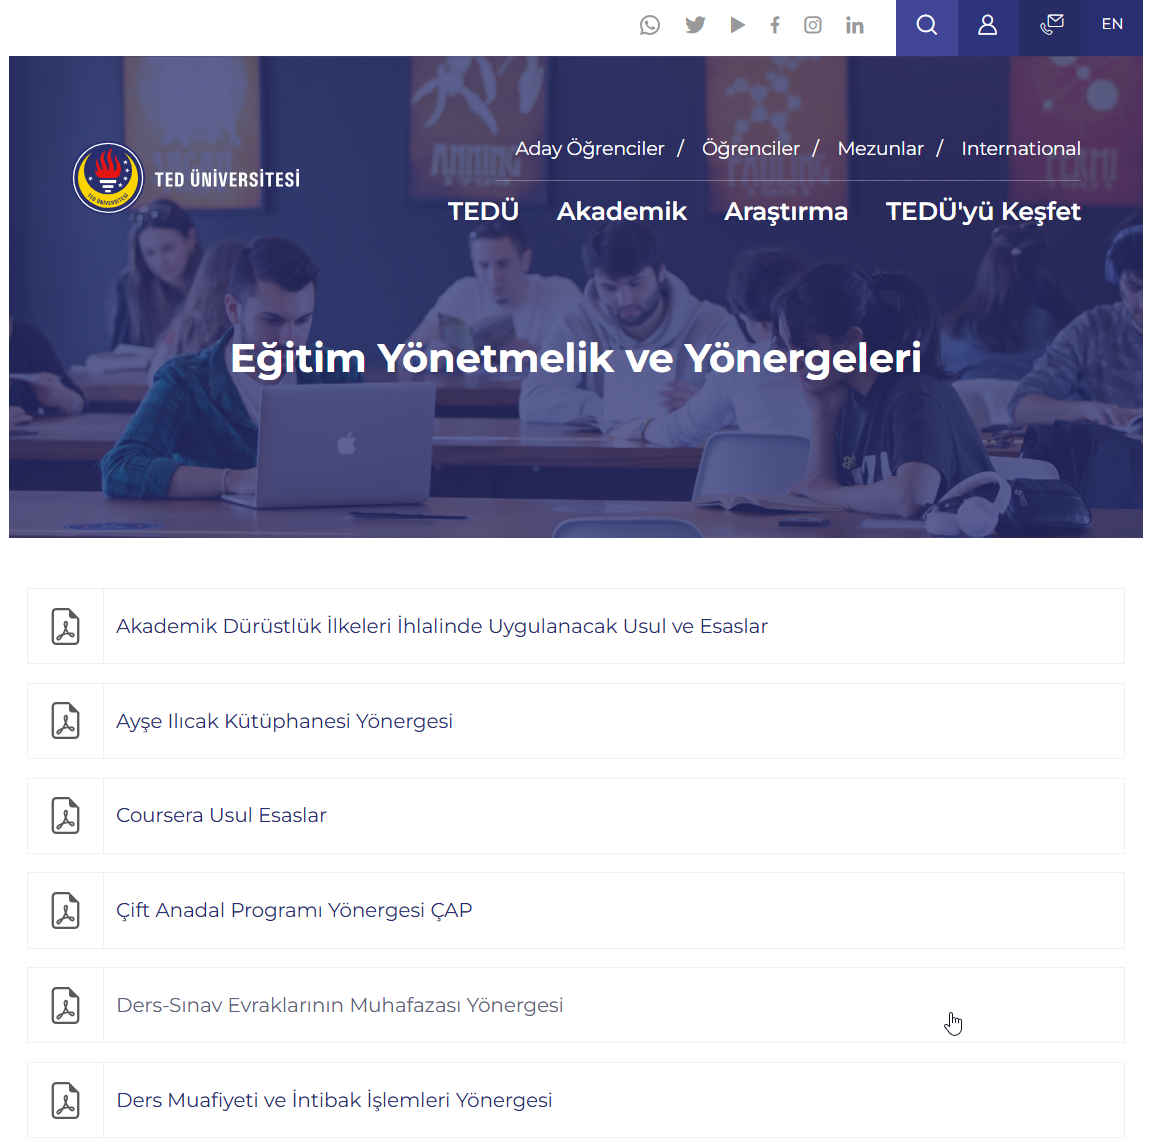

### Belgelerin Toplanması:
PDF dosyaları, Word belgeleri, web sayfaları, kurumsal dokümanlar veya kullanıcı tarafından yüklenen içerikler bilgi tabanını oluşturur.

BU maksatla, örnek çalışma olarak seçtiğimiz TED Üniversitesi’nin  yönetmelikleri kurumsal web sitesinden toplanır: https://www.tedu.edu.tr/egitim-yonetmelik-ve-yonergeleri.

Bu belgeler [Github Murat Karakaya](https://github.com/kmkarakaya/btk_rag_bot_egitimi) deposunda mevcuttur.






Öncelikle Bilgi Tabanımızı (Knowledge Base) handi dizinde tutacağımıza karar verelim:

In [ ]:
# İndirilecek dosyaların kaydedileceği dizin
knowledge_base_path = "./knowledgeBase"

Aşağıdaki kod yardımıyla bu  belgeleri Colab ortamına indirebiliriz.

In [ ]:
# @title Örnek Belgeleri GitHub'dan İndir
import requests
from urllib.parse import quote
import os
import shutil

# GitHub repository bilgileri
owner = "kmkarakaya"
repo = "btk_rag_bot_egitimi"
folder_path = "Örnek Bilgi Tabanı"

# knowledge_base dizini varsa sil ve yeniden oluştur, yoksa oluştur
if os.path.exists(knowledge_base_path):
    print(f"'{knowledge_base_path}' dizini mevcut. Siliniyor...")
    shutil.rmtree(knowledge_base_path)
    print(f"'{knowledge_base_path}' dizini silindi.")
os.makedirs(knowledge_base_path)
print(f"'{knowledge_base_path}' dizini oluşturuldu.")


# API endpoint
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{quote(folder_path)}"

print("GitHub API'ye bağlanılıyor...")
try:
    response = requests.get(api_url)
    response.raise_for_status()

    files = response.json()
    pdf_files = [f for f in files if f['name'].lower().endswith('.pdf')]

    print(f"{len(pdf_files)} PDF dosyası bulundu:")

    downloaded_files = []

    for file in pdf_files:
        print(f"\nİndiriliyor: {file['name']}")

        try:
            file_response = requests.get(file['download_url'])
            file_response.raise_for_status()

            # Dosya yolunu knowledge_base_path içine ayarla
            file_path = os.path.join(knowledge_base_path, file['name'])

            with open(file_path, 'wb') as f:
                f.write(file_response.content)

            file_size = len(file_response.content)
            print(f"✓ {file['name']} indirildi ({file_size:,} bytes)")
            print(f"  Konum: {file_path}")
            downloaded_files.append(file_path)

        except Exception as e:
            print(f"✗ {file['name']} indirilemedi: {e}")

    print(f"\n🎉 Toplam {len(downloaded_files)} PDF dosyası indirildi!")
    print("\nİndirilen dosyalar:")
    for file_path in downloaded_files:
        print(f"📄 {file_path}")

except Exception as e:
    print(f"API hatası: {e}")
    import traceback
    traceback.print_exc()

### 📂 PDF Belgelerini Yükleme



#### 🎯 Amaç:
Bu adımda, Bilgi Veritabanı oluşturmak üzere kullanacağımız tüm **PDF belgelerini sisteme yükleyecek ve işlemeye hazır hale getireceğiz**. Belgeler, gömülü metin içerikleri çıkarılmak üzere dizinler içinde organize edilir ve döngü ile taranır.


#### 📌 Neden Bu Aşama Gereklidir?

- RAG (Erişim Destekli Metin Üretimi) sistemleri, bilgi tabanı olarak yapılandırılmış içeriklere ihtiyaç duyar.
- Bu içerikler genellikle PDF belgeleri şeklinde saklanır: kılavuzlar, teknik dökümanlar, raporlar, vb.
- Tüm belge dosyalarını sisteme yükleyip, ilerleyen adımlarda her birini ayrı ayrı metne çevirmek üzere bir listeye veya sözlük yapısına kaydetmek gerekir.



| Dikkat Edilecek Nokta                                               | Açıklama                                                 |
| ------------------------------------------------------------------- | -------------------------------------------------------- |
| 🔡 Dosya adları temiz ve anlamlı olmalı                             | Belge kaynağının izlenebilirliği için önemli.            |
| 🗂️ Klasör yolu sabit ve tek yerde tanımlı olmalı                   | Kodun taşınabilirliğini artırır.                         |
| 📃 Farklı formatlar filtrelenmeli                                   | `.docx`, `.txt`, `.jpg` gibi dosyalar işleme alınmamalı. |
| 🧪 Gerekirse test için örnek bir veya iki PDF dosyasıyla başlanmalı | Tüm süreci küçük ölçekte görmek için.                    |


#### **UYGULAMA**

In [ ]:
import os
def create_knowledge_base(knowledge_base_path):
  # İndirilen dosya yollarını tutacak boş bir liste oluşturun
  downloaded_files = []

  # Belirtilen dizindeki tüm dosya ve klasörleri listele
  for item in os.listdir(knowledge_base_path):
      # Tam dosya yolunu oluştur
      item_path = os.path.join(knowledge_base_path, item)
      # Eğer öğe bir dosyaysa ve '.pdf' ile bitiyorsa
      if os.path.isfile(item_path) and item_path.lower().endswith('.pdf'):
          # Sadece dosya adını listeye ekle
          downloaded_files.append(item)

  # Bulunan PDF dosyalarını yazdır
  print(f"'{knowledge_base_path}' dizininde bulunan PDF dosyaları:")
  for file_path in downloaded_files:
      print(f"📄 {file_path}")

  print(f"\nToplam {len(downloaded_files)} PDF dosyası bulundu.")
  return downloaded_files

In [ ]:
knowledge_base = create_knowledge_base(knowledge_base_path)


#### ✅ Bu Adımın Çıktısı:
Bu işlemin sonunda elimizde:

- PDF dosya adlarını içeren bir liste (knowledge_base)

- Her dosyanın içeriğini çıkarabilmemiz için tam yolları hazırdır.

Sonraki adımda bu belgelerden **sayfa bazlı metin çıkarımı** yapacağız.

##⛏️Belgelerden Metin  Çıkarımı (Text Extraction):

Bu bölümde, PDF formatındaki ham belgelerden **yapılandırılmış düz metin verisi** nasıl elde edilir sorusuna odaklanıyoruz.  
**Bilgi tabanının ilk adımı**, belgelerin içeriğinin okunabilir, işlenebilir ve analiz edilebilir hale getirilmesidir.


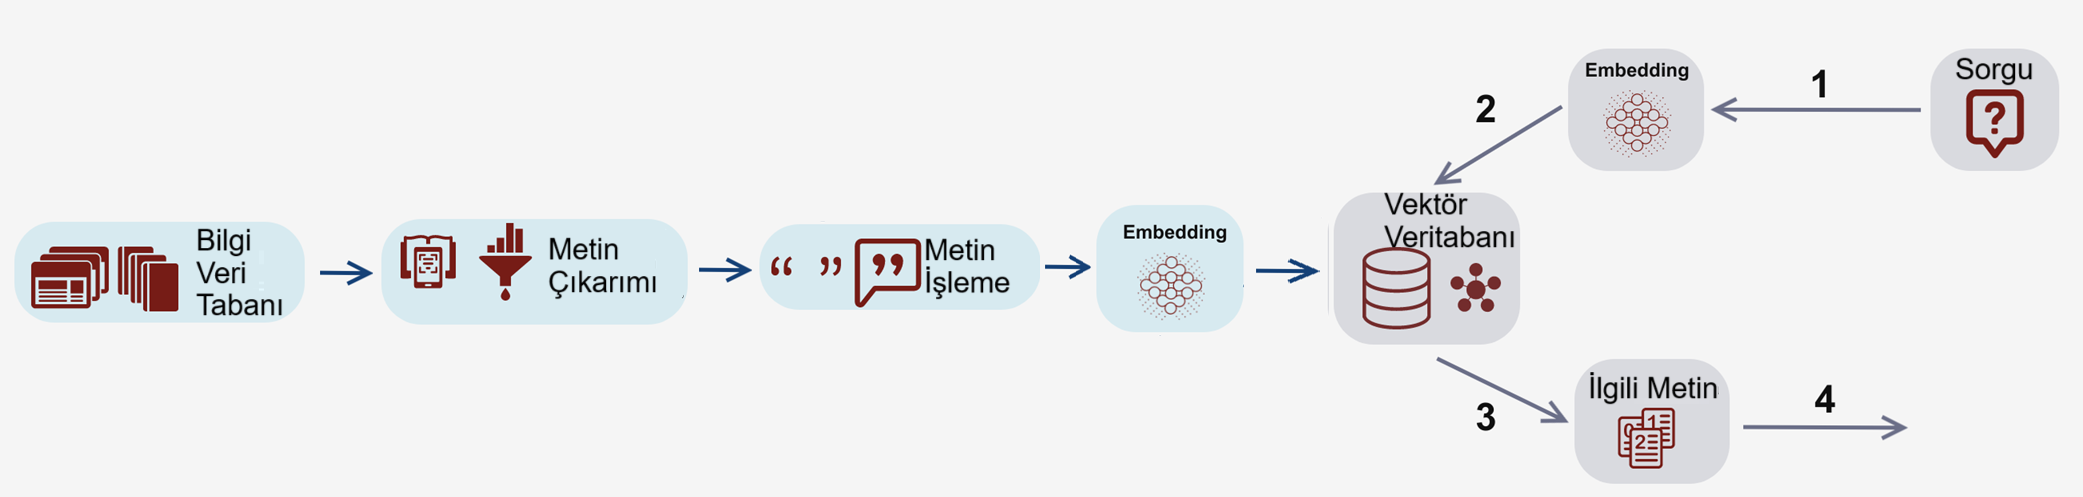

### 📄 Neden Gerekli?

- Çoğu kurumsal bilgi PDF gibi belgelerde saklanır.
- Ancak bu belgeler üzerinde **doğrudan semantik arama veya gömme işlemi yapılamaz.**
- Bu nedenle, PDF sayfalarındaki içerikleri **doğal dil metnine** dönüştürmek gerekir.
- Bu işlem, hem içerik analizinin hem de sonraki parçalama ve embedding adımlarının temelini oluşturur.


### ⚙️ Kullanılan Araç: `PyPDF2`

Bu kütüphane, PDF dosyalarındaki metni sayfa sayfa çıkarmak için kullanılan yaygın bir Python aracıdır.  
Her sayfa için `.extract_text()` yöntemiyle metin elde edilir. Ancak karmaşık PDF’lerde yerleşim sorunlarına karşı dikkatli olmak gerekir.

> 📚 Alternatif: Eğer daha gelişmiş layout desteği gerekiyorsa `PyMuPDF (fitz)` veya `pdfplumber` kütüphaneleri tercih edilebilir.


### 🛠️ Uygulama Adımları

1. PDF dosyaları, önceden belirlenmiş bir dizine yüklenir.
2. Her PDF sayfası döngüyle okunur.
3. Sayfadaki metin temizlenerek **bir liste veya sözlük** yapısında saklanır.
4. Her belge için `"dosya_adi → sayfa_içeriği"` eşleşmesi oluşturulur.

### UYGULAMA:
Öncelikle PDF türü dosyaları işleyebilen bir Python kütüphanesini yükleyelim ve kullanalım.

In [ ]:
%pip install -q PyPDF2
import PyPDF2

Verilen dizindeki PDF belgesini sayfa sayfa metine çeviren bir yardımcı fonksiyon yazalım:

In [ ]:
import PyPDF2

def convert_PDF_Text(knowledge_base_path, file_name):
  file_path= os.path.join(knowledge_base_path, file_name)
  try:
    # Belirtilen PDF dosyasını okumak için PdfReader nesnesi oluştur
    reader = PyPDF2.PdfReader(file_path)

    # Her sayfadan metni çıkar ve baş/son boşlukları temizle
    pdf_pages = [p.extract_text().strip() for p in reader.pages]
    # Boş metin dizilerini filtrele
    pdf_pages = [text for text in pdf_pages if text]
    # Belge adını ve işlenen sayfa sayısını yazdır
    print("📗", file_name,"yükleniyor...\nToplam ", len(pdf_pages), " Sayfa yüklendi ",)
    # Metin sayfalarının listesini döndür
    return pdf_pages
  except Exception as e:
    print(f"🚩Hata oluştu: {file_path} dosyası işlenemedi. Hata: {e}")
    return [] # Hata durumunda boş liste döndür

In [ ]:
pdf_pages=convert_PDF_Text(knowledge_base_path, knowledge_base[0])

Metinleri formatlı olarak bastırmak için küçük bir yardımcı fonksiyon yazalım:

In [ ]:
import textwrap
from IPython.display import display
from IPython.display import Markdown

def to_markdown(text):
  # Markdown formatına uygun hale getir, madde işaretlerini düzelt
  text = text.replace('•', '  *')
  # Metni girintile ve Markdown nesnesi olarak döndür
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

İlk belgenin ilk sayfasındaki metine göz atalım:

In [ ]:
to_markdown(pdf_pages[0])

### **Ev Ödevi**

Bu eğitim süresince, bilgi tabanını oluşturmak amacıyla PDF formatındaki belgeler kullanılacaktır. Ancak, bu sadece başlangıç noktasıdır. Geliştirilen sistem, diğer belge türlerini (örneğin ***Word, HTML, TXT*** gibi) destekleyecek şekilde kolaylıkla genişletilebilir. Ev ödevi olarak yazacağınız yardımcı bir fonksiyon ile diğer tip belgelerdeki metinleri çıkartmayı deneyiniz.


## 🏭Metin İşleme (Chunking):





### 📌 Neden Metni Parçalamalıyız?

Gömme modelleri (embedding models), metinleri **sayısal vektörlere dönüştürmeden önce**, bu metinlerin uzunluğuna dikkat eder.  
Her Gömme (embedding) modelinin **maksimum token sınırı** vardır — örneğin:

- `distiluse-base-multilingual-cased-v1` → 512 token
- `all-MiniLM-L6-v2` → 384 token
- `text-embedding-ada-002` → 8192 token

📉 Eğer bu sınır aşılırsa:

- Model metni kesebilir → bilgi kaybı yaşanır  
- Hata verebilir veya eksik embedding üretir  
- Bazı modeller hiç çalışmaz








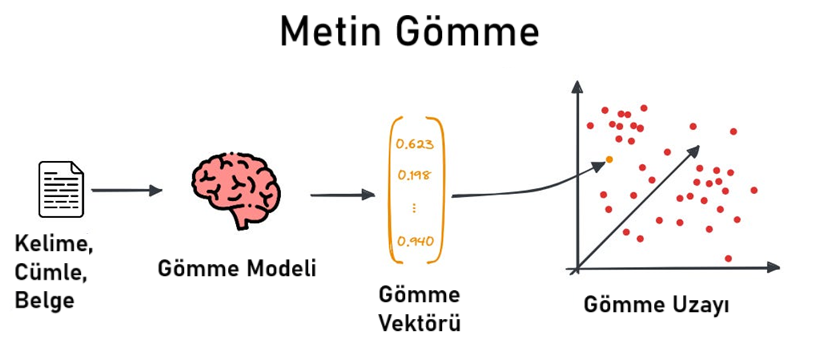

### 🔍 Çözüm: **Metni Küçük ve Anlamlı Parçalara Bölmek (Chunking)**

Bu işleme **metin parçalama (chunking)** denir.  
Amaç: Hem modelin teknik sınırlarına uymak, hem de metin anlamını korumak.

Bu bölümde, PDF belgelerinden elde ettiğimiz uzun metinleri aşağıdaki adımlarla parçalayacağız:

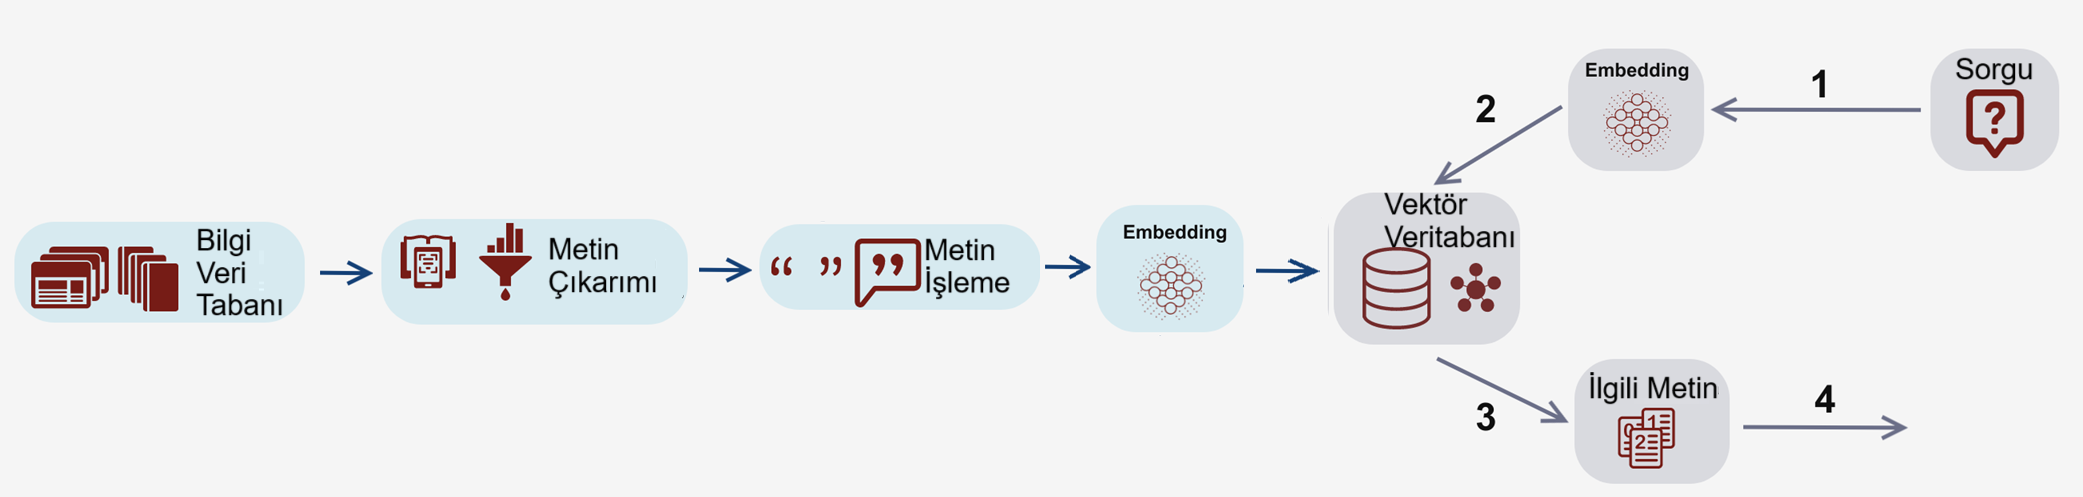

### 🧩 Belgeleri Parçalara Ayırma (Chunking )Adımları

Eğitimde iki aşamalı bir parçalama (chunking) stratejisi uygulanmaktadır. İlk adımda **karakter bazlı parçalama**, ikinci adımda ise bu parçaların **token bazlı olarak yeniden bölünmesi** yapılır.



#### 🔸 1. **Karakter Bazlı Parçalama (Character-based Chunking)**

- 🧱 **Bölme Düzeyi:** Paragraf → Cümle → Kelime → Karakter  
- ⚙️ **Kullanılan Araç:** `RecursiveCharacterTextSplitter`  
- 🎯 **Amaç:** Metni yapısal bütünlüğe (paragraf, cümle vb.) göre bölerek anlamlı parçalar elde etmek.  
- 📐 **Parametreler:**
  - `chunk_size = 1500` → Her bir parçanın maksimum karakter uzunluğu
  - `chunk_overlap = 100` → Komşu parçalar arasında 100 karakterlik çakışma

- 🔍 **Nasıl çalışır?**  
  Belirlenen ayırıcılar (`\n\n`, `\n`, `. `, ` `, ``) sırasıyla denenerek metin mümkün olduğunca anlam bütünlüğü korunarak bölünür.

- 💡 **Örnek Çıktı:**  
  - 1500 karakterlik bir metin parçası  
  - Parçalar cümle ya da paragraf bütünlüğü taşır  
  - Çakışma sayesinde bağlam sürekliliği sağlanır



#### 🔸 2. **Token Bazlı Parçalama (Token-based Chunking)**

- 🧱 **Bölme Düzeyi:** Token (modelin anlayabileceği en küçük dil birimi)  
- ⚙️ **Kullanılan Araç:** `SentenceTransformersTokenTextSplitter`  
- 🎯 **Amaç:** Karakter bazlı oluşturulmuş parçaları, seçilen embedding modelinin desteklediği **maksimum token sınırına** göre yeniden bölmek.  
- 📐 **Parametreler:**
  - `tokens_per_chunk = 128` → Her bir parçanın maksimum 128 token içermesi
  - `chunk_overlap = 0` → Token bazlı parçalarda çakışma uygulanmaz
  - `model_name = "distiluse-base-multilingual-cased-v1"` → Token hesaplamasında kullanılan model

- 🔍 **Nasıl çalışır?**  
  Karakter bazlı her parçanın token'ları sayılır ve gerekirse bu parça daha küçük token gruplarına bölünür. Bu, embedding modeli sınırları içinde kalmak için gereklidir.

- 💡 **Örnek Çıktı:**  
  - Maksimum 128 token içeren anlamlı küçük metin parçaları  
  - Her biri embedding için doğrudan uygun yapıdadır  
  - Modelin teknik sınırlarına tam uyumludur


### ✅ Neden Bu Sıralama?

| Aşama                      | Amaç                                      | Model Uyumluluğu |
|---------------------------|-------------------------------------------|------------------|
| Karakter Bazlı Parçalama  | Anlam bütünlüğü (paragraf/cümle bazlı)    | Yüksek           |
| Token Bazlı Parçalama     | Teknik uygunluk (token sınırına uyum)     | Tam              |

Bu iki aşamalı parçalama sayesinde hem **anlamsal doğruluk** korunur hem de **embedding modelinin teknik kısıtları** aşılmadan verimli bir yapı elde edilir.


### ✅ Sonuç
Bu işlemler sonunda elimizde:

- Her biri maksimum 128 tokenden oluşan

- Anlamlı yapısını büyük oranda koruyan

- Embedding için hazır hale getirilmiş metin parçaları olacaktır.

Bu parçalar bir sonraki adımda embedding modeline verilecek ve vektör veritabanına kaydedilecektir.

🎯 **Unutmayın**: Parçalama ne kadar iyi yapılırsa, bilgiye erişim kalitesi ve üretilen yanıtın doğruluğu o kadar artar.

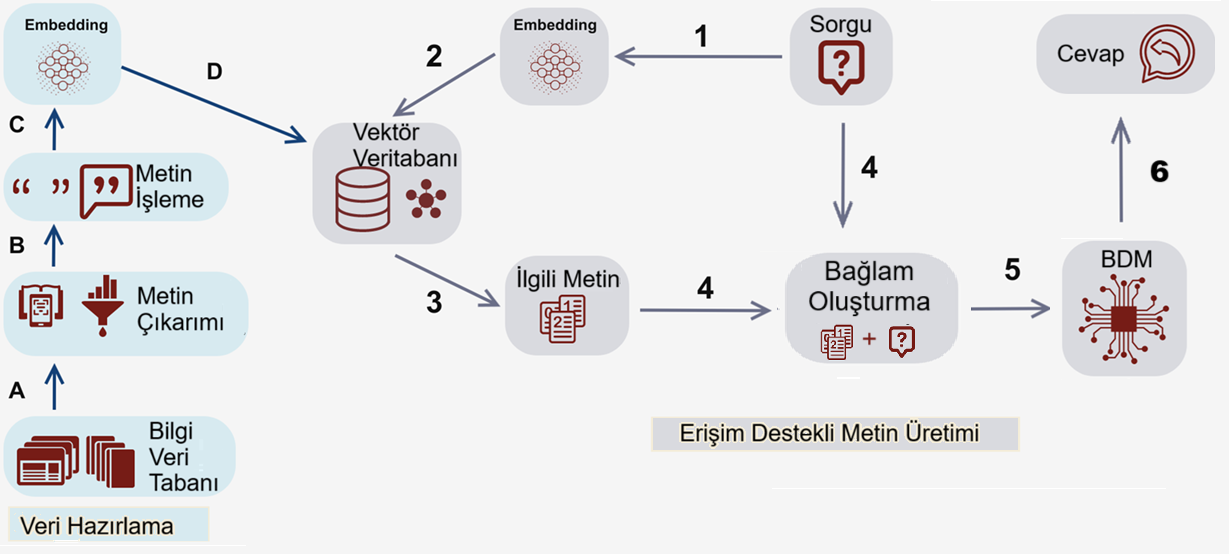

## 🔢 Adım 1: Karakter Bazlı Parçalama

Bu adımda, metinleri nasıl karakter tabanlı olarak bölebileceğimizi öğreneceğiz.

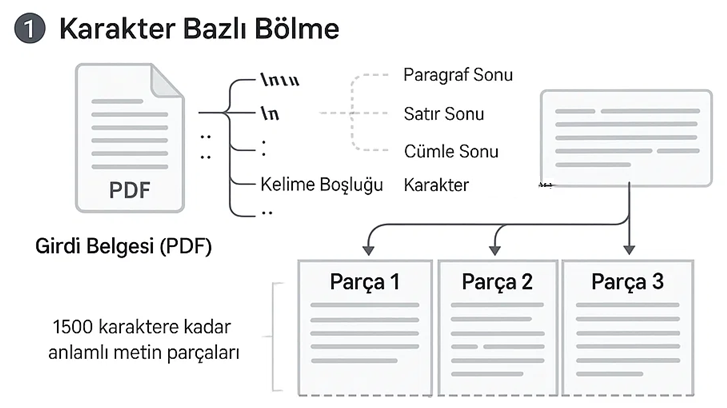



### Kullanılan Yöntem: `RecursiveCharacterTextSplitter`

Kullanacağımız araç, `RecursiveCharacterTextSplitter` adlı sınıftan türetilen bir **karakter tabanlı ayırıcı (character splitter)** nesnesidir. Bu nesne, metni belirli ayırıcılar kullanarak küçük ve anlamlı parçalara ayırır. Bu metin ayırıcı, **genel metinler** için önerilen bir tekniktir. Temel prensibi, bir karakter listesine göre metni **önce büyük yapısal bloklarda (paragraflar), sonra cümle ve kelimelerde** bölerek mümkün olduğunca anlamlı bütünlükleri korumaktır.

### Varsayılan Ayırıcı Listesi (separators):
Aşağıdaki karakterler sırayla denenerek bölme işlemi yapılır:
- `"\n\n"` → Çift satır sonu (paragraf ayracı)
- `"\n"` → Tek satır sonu
- `". "` → Nokta ve boşluk (cümle sonu)
- `" "` → Boşluk (kelime sonu)
- `""` → Boş karakter (karakter bazında son çare)

Ayırıcılar yukarıdaki sırayla denenerek metin bölünür. Amaç, **anlamsal bütünlüğü** en üst düzeyde korumaktır.

### Parametreler

- **`chunk_size` (Parça Boyutu):**  
  Her parçanın alabileceği maksimum karakter sayısını belirler.  
  Örnek: `chunk_size = 1500`

- **`chunk_overlap` (Parça Çakışması):**  
  Parçalar arasında tekrar eden içerik olup olmayacağını belirler.  
  - Örnek: `chunk_overlap = 0` → Parçalar arasında çakışma **yoktur**.
  
  - Örnek: `chunk_overlap = 10` → Önceki parçanın son 10 karakteri sonraki parçanın ilk 10 karakteri olarak **tekrarlanır**.




### Neden Bu İşlemi Yapıyoruz?

Metni karakter tabanlı parçalara (chunk'lara) ayırmamızın asıl amacı, bu parçaları ileride bir **gömme modeli (embedding model)** ile **vektörlere dönüştürebilmektir**. Ancak gömme modelleri, girdiler için belirli bir **maksimum token sınırı** ile çalışır (örneğin: 512, 1024 veya 2048 token).

Eğer bir metin bu sınırı aşarsa, model:

- Girdiyi keserek eksik vektör üretir
- Hata verir veya düşük kaliteli çıktı üretir

Bu yüzden metni **önceden bölmek**, gömme işlemi için **hazırlık** anlamına gelir.

Bu şekilde:

- Her parça modelin kabul ettiği sınırda olur
- Semantik olarak anlamlı kalır
- RAG sistemleri, bu parçalardan doğru bilgiyi hatırlayıp daha güvenilir ve bağlama uygun yanıtlar üretebilir


> 🎯 **Unutmayın:**  
> Bu teknik, ileri aşamalarda uygulanacak **vektörleştirme (embedding)** ve **vektör veritabanına (vector database)** içerik ekleme işlemleri için temel oluşturur. Doğru parçalama yapılmazsa, LLM’in hatırlama ve anlamlandırma yeteneği ciddi şekilde zayıflar.


### **UYGULAMA**

In [ ]:
# Langchain kütüphanesini yükle (eğer yüklü değilse)
%pip install langchain --quiet
import langchain

# Metinleri parçalara ayırmak için gerekli sınıfları içe aktar
from langchain.text_splitter import RecursiveCharacterTextSplitter, SentenceTransformersTokenTextSplitter

In [ ]:
def convert_Page_ChunkinChar(pdf_texts, chunk_size = 1500, chunk_overlap=200 ):
  # Karakter tabanlı metin ayırıcı nesnesi oluştur
  character_splitter = RecursiveCharacterTextSplitter(
      # Ayırıcı karakterleri tanımla
      separators=["\n\n", "\n", ". ", " ", ""],
      # Her parçanın maksimum karakter boyutunu belirle
      chunk_size=chunk_size,
      # Parçalar arasındaki çakışma miktarını belirle
      chunk_overlap=chunk_overlap
  )
  # PDF metinlerini belirtilen ayırıcılar ve boyutlarla parçalara ayır
  character_split_texts = character_splitter.split_text('\n\n'.join(pdf_texts))
  # Toplam parça sayısını yazdır
  print(f"Toplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = {chunk_size}): \
        {len(character_split_texts)}")
  # Oluşturulan metin parçalarının listesini döndür
  return character_split_texts

In [ ]:
to_markdown(pdf_pages[0])

In [ ]:
# convert_Page_ChunkinChar fonksiyonunu çağır
# pdf_pages listesindeki ilk öğeyi (ilk sayfa) metin olarak gönder
# chunk_size=500 ve chunk_overlap=100 parametrelerini kullan
character_split_texts = convert_Page_ChunkinChar(pdf_pages, chunk_size = 500, chunk_overlap=100 )

In [ ]:
to_markdown(character_split_texts[0])

In [ ]:
to_markdown(character_split_texts[1])

**DİKKAT**:

`chunk_overlap=100` verilmesi nedeniyle bir önceki metin parçası ile bir sonraki metin parçası arasındaki ortak metine "***Madde 1 - (1) Bu yönergenin amacı, TED Üniversitesi’nin herhangi bir lisans diploma programına***" dikkat ediniz.  

### 📌 **EV ÖDEVİ: `chunk_overlap` Parametresini Anlamak**

🔍 Aşağıdaki sorulara düşünerek kısa ama açık bir yanıt verin:

#### ✅ Soru:
`chunk_overlap` parametresinin değerini neden **0'dan büyük** bir sayı olarak ayarlamak isteyebiliriz?  
Bu yaklaşımın **avantajları** ve **olası dezavantajları** nelerdir?

---

### 💡 İPUCU:

`chunk_overlap`, ardışık metin parçaları (chunk'lar) arasında **tekrarlanan karakter sayısını** belirler. Yani bir metin parçasının son kısmı, bir sonraki parçanın başına da eklenir. Bu sayede parçalar arasında **bağlam geçişi daha yumuşak** olur.

#### Düşünmen gereken bazı noktalar:
- Eğer bir bilgi ya da cümle bir parçanın sonunda kalıyorsa ve `chunk_overlap=0` ise bu bilgi **bir sonraki parçada görünmez**.
- `chunk_overlap` sayesinde **uzun cümleler veya paragraflar** daha sağlıklı bir şekilde korunabilir.
- Ancak overlap değeri fazla olursa, bazı metin parçaları **aynı içeriği tekrar tekrar** içerir. Bu da veri boyutunu artırır ve **gereksiz tekrarlarla maliyet** doğurabilir.

---

### 🎯 Amaç:
Bu ödevle, parçalama stratejisinin RAG sistemlerinin doğruluğunu, maliyetini ve performansını nasıl etkileyebileceğini kavraman bekleniyor.

İstersen farklı `chunk_overlap` değerleriyle örnek parçalamalar yaparak gözlemleyebilirsin:
```python
convert_Page_ChunkinChar(text, chunk_size=500, chunk_overlap=0)
convert_Page_ChunkinChar(text, chunk_size=500, chunk_overlap=100)


In [ ]:
len(character_split_texts[0]), len(character_split_texts[1])

> ❓ **Neden parça uzunlukları (chunk) tam olarak 500 değil?**
>
> `convert_Page_ChunkinChar()` fonksiyonu, metni karakter bazında bölmek için `RecursiveCharacterTextSplitter` sınıfını kullanır. Bu sınıf, parçaları belirli **ayırıcı karakterler** (örneğin: "\n\n", "\n", ".", " ") kullanarak böler.
>
> Bu sayede cümleler veya paragraflar kesilmeden bir bütün olarak korunur. Yani, parça uzunluğu **"tam olarak 500 karaktere eşit olsun"** diye değil, **"yaklaşık 500 karakter uzunluğunda ama mümkünse anlam bütünlüğü bozulmadan"** olsun diye tasarlanmıştır.
>
> Örneğin:
> - 1. parça: 412 karakter
> - 2. parça: 495 karakter  
>
> Bu, seçilen ayırıcıya en yakın noktada bölme yapılmasından kaynaklanır.
>
> 📌 Bu durum bilinçli bir tercihtir ve özellikle RAG sistemlerinde metin anlamını korumak için **önerilen bir yaklaşımdır**.


#### Bir PDF'in tüm sayfalarını `chunk_size = 1500, chunk_overlap=200` parametrelerine göre parçalayalım:  

In [ ]:
# convert_Page_ChunkinChar fonksiyonunu çağırarak ilk PDF in sayfalarını
# karakter tabanlı parçalara böl
text_chunksinChar = convert_Page_ChunkinChar(pdf_pages, chunk_size = 1500, chunk_overlap=200 )
# Bilgilendirme mesajları yazdır
print("................. DİKKAT ..................")
# Belge adını ve toplam sayfa sayısını yazdır
print(downloaded_files[0]," belgesinin ")
print("toplam ", len(pdf_pages), " sayfası var")
# Belge adını ve oluşturulan parça sayısını yazdır
print("toplam ", len(text_chunksinChar), " parçaya (chunks) ayrılmıştır")
# İlk parçanın karakter sayısını yazdır
print("ilk parçanın içeriği toplam ", len(text_chunksinChar[0]), " karakterdir")
# Son parçanın karakter sayısını yazdır
print("son parçanın içeriği toplam ", len(text_chunksinChar[-1]), " karakterdir")

## 🔢 Adım 2: Token Bazlı Parçalama



Bu adımda, önceki adımda ***karakter bazlı olarak parçalara (chunk'lara) ayrılmış olan metinler*** bu kez **token** bazında tekrar bölünür. Bu işlem, metni doğal dil işleme (NLP) modelleri tarafından daha hassas işlenebilecek bir yapıya sokmak için yapılır. Bunun için `SentenceTransformersTokenTextSplitter` adlı özel bir sınıf kullanılmaktadır.


Bu tür bir bölme, özellikle **gömme (embedding)** işlemi veya daha ileri NLP görevleri (sınıflandırma, soru-cevap, vb.) için oldukça yararlıdır. Token bazlı bölme, modelin maksimum token kapasitesini aşmadan anlamlı girişler üretmeyi sağlar.

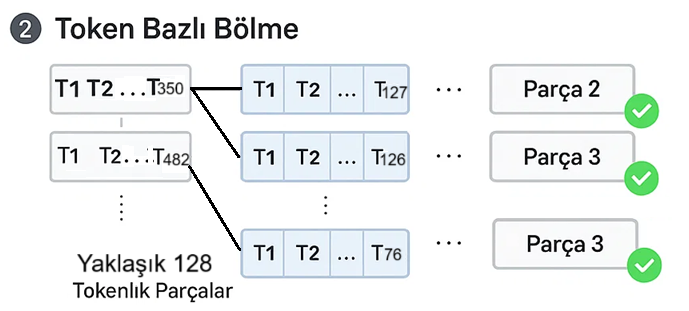



#### 🛠 Kullanılan Araçlar:
- `SentenceTransformersTokenTextSplitter`: Bu sınıf, metni bir cümle gömme modeli temelinde token bazında bölmek için kullanılır.

- `distiluse-base-multilingual-cased-v1`  
Bu örnekte kullanılan gömme (embedding) modelidir. Bu model çok dilli destek sunar ve Türkçe dâhil birçok dilde etkilidir. Özellikleri:  
  ✅ 15 dili destekler, **Türkçe** dahil.  
  ✅ Çok dilli projeler için ideal.  
  ✅ `sentence_transformers` kütüphanesi ile çalışır.
  ✅ Girdinin maksimum token uzunluğu: **128 token**dur.

### 💡 Neden Önce Karakter Sonra Token Bazlı Bölme Yapıyoruz?


- **Karakter bazlı bölme**, metni öncelikle anlamlı yapılar (paragraf, cümle vb.) üzerinden mantıklı parçalara ayırır.
- **Token bazlı bölme**, bu parçaları ***embedding modelinin*** işleyebileceği token sınırına göre daha küçük birimlere böler.

- Token bazlı bölme işlemi, karaktere göre daha hassas bir kontrol sağlar çünkü:
 - Bir kelime 3-4 token’a denk gelebilir.
 - Gömme (Embedding) Modelin kapasitesi token sayısıyla sınırlıdır, karakter sayısıyla değil.

Bu iki adım birlikte kullanıldığında:
- Hem **anlam bütünlüğü** korunur,
- Hem de Gömme (Embedding) Modelinin **teknik sınırlamalara** (token limiti) uygunluk sağlanır.



### ✅ Sonuç

Bu iki parçalama adımının ardından elimizde şu özelliklere sahip metin parçaları olur:

✅ Her biri **anlamlı**,  
✅ Maksimum **128 token** içeren,  
✅ Gömme modeline **uygun** metin parçaları.

Bu parçalar artık **embedding (vektörleştirme)** işlemine hazırdır ve bir **vektör veri tabanı** oluşturmada doğrudan kullanılabilir.



### **Uygulama**

### Token nedir?
Token kavramını anlamak için aşağıdaki örneğe bakalım.
(Sentence Transformers modelleri için bu [bağlantıyı](https://www.sbert.net/docs/sentence_transformer/pretrained_models.html) kullanınız.)

Aşağıda önce `sentence-transformers` kütüphanesinden `distiluse-base-multilingual-cased-v1` gömme (embedding) modelini HuggingFace deposundan inireceğiz ve kullanacağız.

In [ ]:
from transformers import AutoTokenizer

# Belirtilen Sentence Transformer modelinin tokenizer'ını yükle
# Bu modelin tokenizer'ı, metni modelin anladığı token'lara ayırmak için kullanılır.
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/distiluse-base-multilingual-cased-v1")

# Token sayısını merak ettiğiniz metin parçacığını seçin (örneğin ilk parça)
sample_chunk = """Erişim destekli metin üretimini öğreniyorum. Çok zevkli konular!"""
print(f"Verilen metin: {sample_chunk}")
# Verilen metini tokenlara bölelim ve alt alta yazdırın
print("\nMetnin Token olarak parçalanması:")
tokens = tokenizer.tokenize(sample_chunk)
for token in tokens:
  print(token)

**Not**: Bir alt kelime biriminin başında "##" olması, bu birimin kendisinden önceki alt kelime birimine bitişik olduğunu ve tam bir kelimenin parçası olduğunu gösterir.

In [ ]:
# verilen metni token numaralarına çevirin
print(f"Verilen metin: {sample_chunk}")
token_list= tokenizer.encode(sample_chunk)
print(f"Token numaraları:{token_list}" )

# Token sayısını hesapla
# encode() metodu, metni token ID'lerine dönüştürür.
# len() fonksiyonu, bu token ID'lerinin sayısını verir.
token_count = len(token_list)-2
# 101 ve 102 numaralı tokenlar metnin başı ve sonunu gösterir.

# Sonucu yazdır
print(f"Verilen metin parçacığındaki token sayısı: {token_count}")

In [ ]:
# Her bir Token numarasının metin karşılığını yazdıralım:
for token_id in token_list:
  print(f"token numarası: {token_id} metin karşılığı: {tokenizer.decode(token_id)}")

### Metni istenilen token uzunluğuna göre ayıran Fonksiyonu yazalım

Bunun için önce `sentence_transformers` kütüphanesini indirelim ve yükleyelim:

In [ ]:
# sentence_transformers kütüphanesini yükle (eğer yüklü değillerse)
# sentence_transformers: Metinleri vektörlere dönüştürmek için kullanılır (embedding).
%pip install sentence_transformers --quiet

In [ ]:
# Metinleri token bazlı parçalara ayırmak için gerekli sınıfı içe aktar
from langchain.text_splitter import SentenceTransformersTokenTextSplitter

# Kullanılacak Sentence Transformer modelinin adını tanımla
# Bu model, metin parçalarını tokenlara ayırmak ve embedding işlemi için kullanılacak.
sentence_transformer_model="distiluse-base-multilingual-cased-v1"

In [ ]:
# Metinleri token bazlı parçalara ayıran yardımcı fonksiyon
def convert_Chunk_Token(text_chunksinChar,
                        sentence_transformer_model,
                        chunk_overlap=10,
                        tokens_per_chunk=128 ):
  # SentenceTransformersTokenTextSplitter nesnesi oluşturuluyor
  token_splitter = SentenceTransformersTokenTextSplitter(
      chunk_overlap=chunk_overlap, # Parçalar arası çakışma miktarı
      model_name=sentence_transformer_model, # Kullanılacak tokenizer modelinin adı
      tokens_per_chunk=tokens_per_chunk) # Her bir parçadaki maksimum token sayısı

  # Tokenlara ayrılmış metin parçalarını tutacak boş liste
  text_chunksinTokens = []
  # Karakter bazlı parçalar üzerinde döngü
  for text in text_chunksinChar:
      # Her bir karakter bazlı parçayı tokenlara ayır ve listeye ekle
      text_chunksinTokens += token_splitter.split_text(text)
  # Bilgilendirme mesajı yazdır
  print(f"""\nBelge {tokens_per_chunk} token'lık parçalara bölündüğünde,
  ve çakışma token sayısı {chunk_overlap} olduğunda
  toplam parça sayısı: {len(text_chunksinTokens)}""")
  # Tokenlara ayrılmış metin parçaları listesini döndür
  return text_chunksinTokens

In [ ]:
# convert_Chunk_Token fonksiyonunu çağırarak karakter bazlı parçaları token bazlı parçalara dönüştür
text_chunksinTokens = convert_Chunk_Token(text_chunksinChar,
                                          sentence_transformer_model,
                                          chunk_overlap=10,  # Parçalar arası çakışma miktarı
                                          tokens_per_chunk=128) # Her bir parçadaki maksimum token sayısı

**Token bazlı parçalanmayı** dikkate alınız:

In [ ]:
print("................. DİKKAT ..................")
# Belge adını yazdır
print(f"Belge: {downloaded_files[0]}")
# Belgenin toplam sayfa sayısını yazdır
print("\t toplam ", len(pdf_pages), " sayfası var")
# Belgenin 1500 karakterle ayrılan parça sayısını yazdır
print("\t toplam ", len(text_chunksinChar), " parçaya (chunks) ayrılmıştır (1500 karakter ile)")
# Belgenin 128 tokenle ayrılan parça sayısını yazdır
print("\t toplam ", len(text_chunksinTokens), " parçaya (chunks) ayrılmıştır (128 token ile)")


In [ ]:
# Her parçanın token sayısını yazdır aynı olmayabilir. Neden?
print("\n Her bir parçanın Token sayısı: ")
for i in range(len(text_chunksinTokens)):
  print(f"\t Parça {i}: {len(tokenizer.encode(text_chunksinTokens[i]))-2} ")

In [ ]:
# Token bazlı ilk 3 parçayı yazdır
print("\n\t Token bazlı parçalanmayı dikkate alınız (text_chunksinTokens ilk 3 parçanın içeriği): ")
for i in range(3):
  print(f"\t\t Parça {i}")
  display(to_markdown(text_chunksinTokens[i]))

In [ ]:
# Karakter bazlı ilk parçayı yazdır
print("\n\t Karakter bazlı parçalanmayı hatırlayınız: (text_chunksinChar [0] içeriği): ")
display(to_markdown(text_chunksinChar[0]))

### Sonuç:

Bütün bu işlemlerden sonra PDF belgelerinden elde edilen metnin maksimum 128 token dan oluşacak parçalara ayırmamız mümkün olacaktır.



### 🚀 Bir Sonraki Adım:
Artık metin parçaları hazır. Sıradaki adımda bu parçalar **embedding (gömme)** modeliyle **vektörlere** dönüştürülecek ve bir **vektör veri tabanı** (ör. ChromaDB) içinde saklanacaktır.


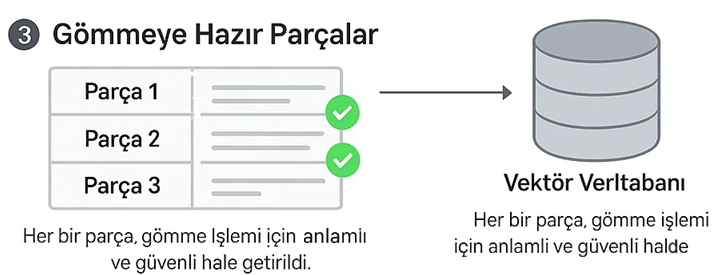

## 🪄Metni Vektöre Çevirme


Büyük Dil Modelleri (LLM) içsel bilgileriyle sınırlıdır. Erişim Destekli Metin Üretimi  (RAG) sistemi, bu sınırı aşmak için dış kaynaklardan alınan bilgiye dayalı **doğruluk oranı yüksek yanıtlar** üretir.  
Ancak dış veri (örneğin PDF metinleri) ile LLM arasında **anlamsal bir köprü** kurmak gerekir.  
Bu köprü, metinlerin **vektörlere (embedding)** dönüştürülmesiyle kurulur.



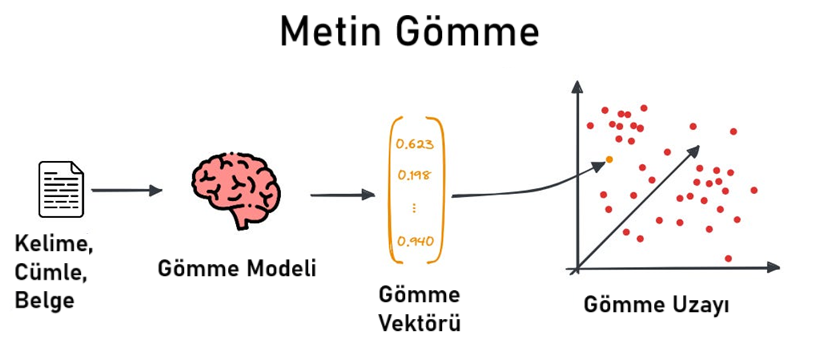

### 🔍 Gömme (Embedding) Nedir?

Gömme (Embedding), bir metni çok boyutlu bir **vektör uzayında sayısal bir temsil** haline getirme işlemidir.  
Bu vektörler, metnin anlamını taşıyacak şekilde modellenir:

- **Benzer anlamdaki metinler** → birbirine **yakın vektörler**
- **Farklı içerikteki metinler** → birbirinden **uzak vektörler**

💡 Örnek:  
"Merhaba, nasılsın?" ve "Selam, iyi misin?" gibi cümleler birbirine yakın vektörlere sahip olur.






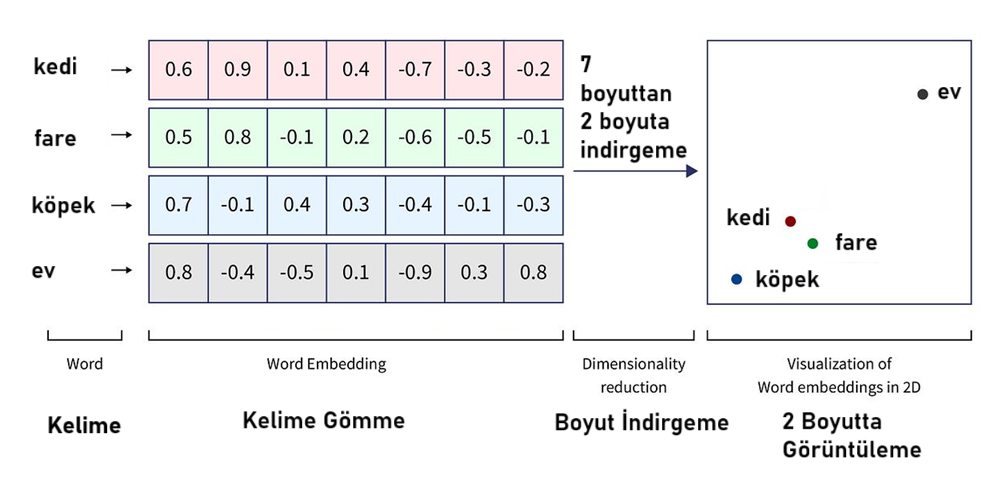

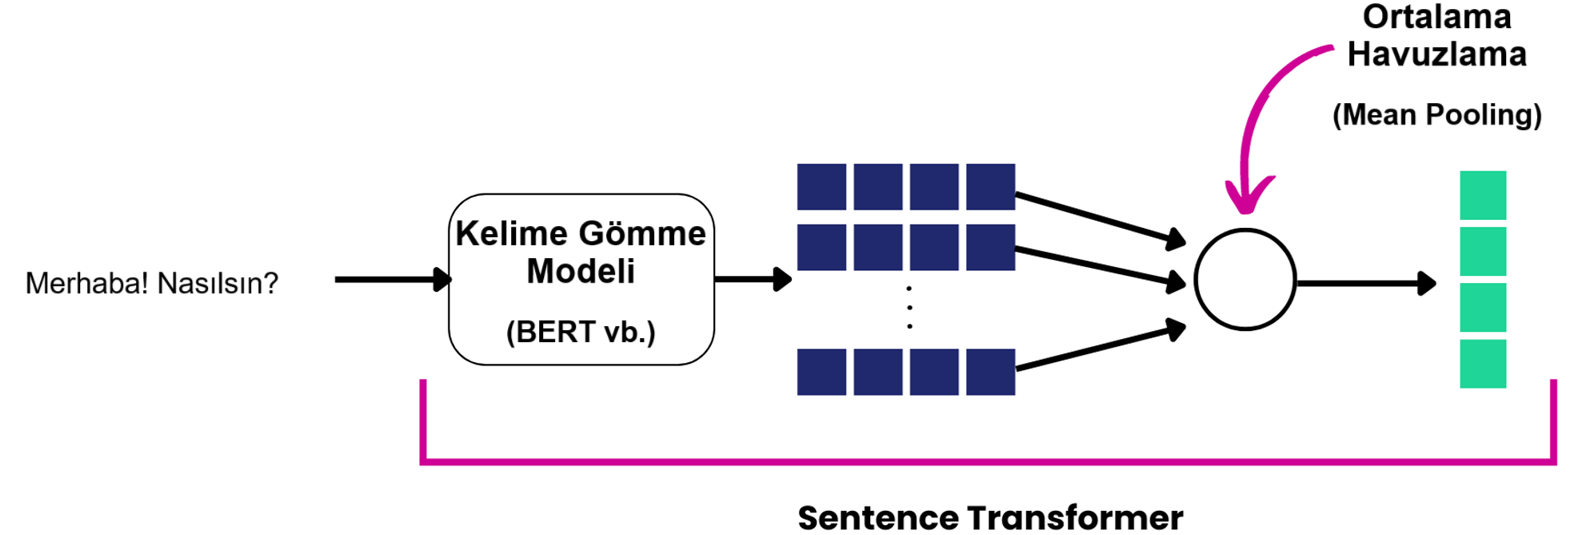

### **Uygulama**

In [ ]:
sample_chunks = [
    "Öğrenci, muafiyet sonuçları ilan edilmesinden itibaren en geç üç ( 3 ) iş günü içerisinde yazılı dilekçeyle ilgili fakülteye başvurarak muafiyetten feragat edebilir.",
    "Muafiyetten feragat eden öğrenci, aynı ders / dersler için bir daha muafiyet veya intibak başvurusunda bulunamaz.",
    "Güz ve bahar yarıyılları ile yaz okulunda verilecek dersler, ilgili bölüm başkanlıklarının önerisi üzerine Üniversite Yönetim Kurulu tarafından karara bağlanır.",
    "Senato tarafından uygun görülmesi halinde lisans programlarındaki bazı dersler uzaktan öğretim yoluyla verilebilir." ,
    "Verilecek derslerin grupları, kapasiteleri ve derslere ilişkin koşullar ilgili bölüm başkanlıkları tarafından belirlenir.",
  ]

In [ ]:
from sentence_transformers import SentenceTransformer
# gömme (embedding) modelini seç
sentence_transformer_model = "distiluse-base-multilingual-cased-v1"
# Modeli yükle
model = SentenceTransformer(sentence_transformer_model)

# Örnek metinleri vektöre çevir
embeddings = model.encode(sample_chunks, show_progress_bar=True)

**NOTE**: Gömme modellerinin çıktı vetör boyutları sabittir. Bu eğitimde kullanılan `distiluse-base-multilingual-cased-v1` modelin çıktısı olan gömme vektörünün boyutu **512** dir.

In [ ]:
len(embeddings[0])

In [ ]:
embeddings[0][:10]

### 🔍 Metin Parçaları Arasında Benzerlik Ölçümü (Similarity)

RAG sistemlerinde yalnızca metin parçalarını vektöre dönüştürmek yeterli değildir. Bu vektörler arasındaki **anlamsal benzerliği ölçmek** de gerekir.

#### 🎯 Neden Benzerlik Ölçümü?

- Kullanıcının sorgusu ile **en anlamsal yakın** metin parçasını bulmak için  
- Gömme vektörlerinin **doğru eşleşmeleri** sağlayıp sağlamadığını test etmek için  
- Hesaplanan vektörlerin **kalitesini doğrulamak** için faydalıdır  






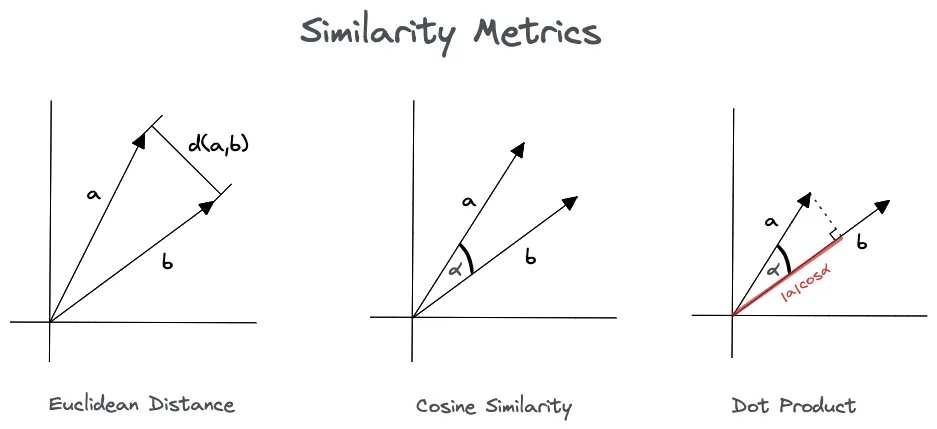

### 📏 1. Öklid Uzaklığı (Euclidean Distance)

* İki vektör arasındaki **doğrudan uzaklığı (mesafeyi)** ölçer.
* Aynı boyutlu düzlemde iki nokta arasındaki mesafeyi hesaplar:

  $$
  d(A, B) = \sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2 + \ldots}
  $$
* Değer aralığı: **0 ve yukarısı**

  * **0** → Aynı vektör (tam benzer)
  * Değer büyüdükçe → **Daha uzak, daha az benzer**

📌 Değer ne kadar **küçükse**, vektörler o kadar **benzer** kabul edilir.

```python
from numpy import linalg as LA
distance = LA.norm(vec1 - vec2)
```





### 📏 2. Kosinüs Benzerliği Nedir?

Kosinüs benzerliği, iki vektör arasındaki açının kosinüsünün değeridir:

$$
\text{cosine_similarity}(A, B) = \frac{A \cdot B}{\|A\| \times \|B\|}
$$



- Değer aralığı: **–1 ile +1**
  - **+1**: İki vektör aynı yönde (tam benzer)
  - **0**: Dik (ilgisiz, anlamsız)
  - **–1**: Zıt yönde (tam ters)

Benzerlik, **vurgunun yönüne** odaklanır; norm (vektör uzunluğu) değil.

### 📏 3. Noktasal Çarpım (Dot Product)

* İki vektörün **bileşenlerinin çarpımının toplamı** alınır.
* Hem **yönü** hem **uzunluğu (magnitüdü)** dikkate alır.
* Formül:

  $$
  \text{dot}(A, B) = a_1 \cdot b_1 + a_2 \cdot b_2 + \ldots
  $$
* Genellikle normalize edilmemiş vektörlerle çalışılır.

📌 Değer ne kadar **büyükse**, vektörler **daha benzer**.

```python
import numpy as np
dot = np.dot(vec1, vec2)
```

### 📌 Değer Aralığı ve Yorumu:
| Dot Product Değeri | Yorumu                                                                                                           |
| ------------------ | ---------------------------------------------------------------------------------------------------------------- |
| **> 0**            | Vektörler arasında **pozitif ilişki** vardır (benzer yönlü). Değer ne kadar büyükse, benzerlik o kadar fazladır. |
| **= 0**            | Vektörler **birbirine dik** (ortogonal) → **hiçbir ilişki yok**.                                                 |
| **< 0**            | Vektörler arasında **negatif ilişki** vardır (zıt yönlü).                                                        |





### 📊 Kıyaslama Tablosu

| Ölçüm Yöntemi          | Ne Ölçer?               | Normalize Gerekir mi? | Yorum                                      |
| ---------------------- | ----------------------- | --------------------- | ------------------------------------------ |
| **Cosine Similarity**  | Yön benzerliği          | Evet (çoğu zaman)     | En yaygın, semantik benzerlikte güçlü      |
| **Euclidean Distance** | Gerçek mesafe (uzaklık) | Hayır                 | Uzaklık temelinde sıralama için kullanılır |
| **Dot Product**        | Hem yön hem büyüklük    | Genellikle hayır      | Ölçek hassas, büyük değerler öncelenir     |

---

## 💡 Hangi Yöntemi Ne Zaman Kullanmalı?

* ✅ **Cosine** → Anlamsal yakınlık, normalize edilmiş veriler, arama motorları, RAG
* ✅ **Euclidean** → Kümeleme (clustering), yakın komşu aramaları (k-NN)
* ✅ **Dot Product** → Ölçekli puanlama (örneğin sınıflandırıcı içinde), transformerlarda dikkat hesaplarında



### **UYGULAMA**

Kosinüs Benzerliğinin hesaplanması:

In [ ]:
import numpy as np
similarities = np.empty(len(embeddings)) # Create an empty numpy array with a size of 4
from sentence_transformers import util
for i in range(5):
  # embeddings[0] ile diğer embeddings ler arasındaki kosinüs benzerliğini hesapla
  similarity = util.cos_sim(embeddings[0], embeddings[i])
  similarities[i] = similarity.item() # Assign the scalar value to the array
  # embedding değerlerini karşılaştıralım
  print(f"Chunk 0: '{sample_chunks[0]}' \nChunk {i}: '{sample_chunks[i]}' \narasındaki kosinüs benzerliği: {similarities[i]} \n")

print("Calculated similarities:", similarities)

### **EV ÖDEVİ**

Öklid Uzaklığı ve Noktasal Çarpım uzaklıklarını hesaplamak için yukarıdaki kodu revize ediniz.

### 🧠 Benzerlik Ölçümünün RAG İçin Önemi
* **Arama/Sorgu Uygunluğu**: Kullanıcının sorgusu ile en uygun metin parçası, vektör veritabanında kosinüs benzerliğine göre bulunur

* **Güvenilirlik**: Doğru parça seçimi, LLM’in yanıtının doğruluğunu artırır

* **Performans**: Vektör benzerliği hızlı hesaplanabilir—skaler ürün ve norm işlemleri bilimsel hızda gerçekleşir


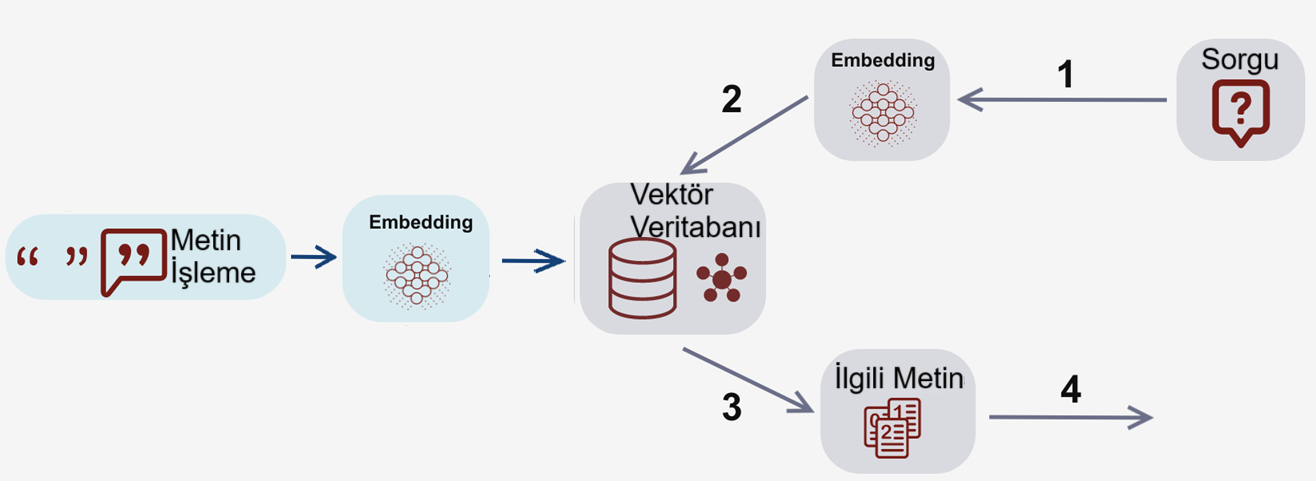

### 🧩 Not: ChromaDB'de Benzerlik Nasıl Tanımlanır?

Bu eğitimde Vektör Veritabanı olarak kullanacağımız [ChromaDB](https://github.com/chroma-core/chroma), embedding uzayında **benzerlik** hesaplamak için kullanılacak **mesafe fonksiyonunu (distance function)**  tanımlarsın. Bu tanım, vektörler arasındaki benzerliğin nasıl ölçüleceğini belirler.

ChromaDB’de desteklenen üç farklı mesafe ölçütü şunlardır:

| Mesafe Tipi                                 | Parametre Adı       | Açıklama                                                                                                                                 |
| ------------------------------------------- | ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| **Kareli L2 Norm** (Squared Euclidean)      | `l2` *(varsayılan)* | Vektörler arasındaki **mutlak geometrik uzaklığı** ölçer. Gerçek uzamsal yakınlık önemliyse tercih edilir. Formül:  $\sum (A_i - B_i)^2$ |
| **Kosinüs Benzerliği** (Cosine Similarity)  | `cosine`            | Vektörlerin **yön benzerliğini** ölçer. Anlamsal yakınlıkta en sık kullanılan ölçüttür.                                                  |
| **İç Çarpım** (Inner Product / Dot Product) | `ip`                | Vektörlerin hem yönünü hem büyüklüğünü dikkate alır. Ölçekli puanlamalarda faydalıdır.                                                   |

📌 **Varsayılan ayar `l2`'dir.** Ancak `cosine` veya `ip` seçilerek sistemin benzerlik yaklaşımı değiştirilebilir.

> 🔍 **Ne zaman `l2`, ne zaman `cosine`?**
>
> * **Gerçek fiziki benzerlik** önemliyse (örneğin görsel embeddinglerde): `l2`
> * **Anlamsal benzerlik**, içerik yakınlığı aranıyorsa: `cosine`
> * **Ölçekli skor üretimi** gerekiyorsa: `ip` (inner product)

Daha fazla bilgi için [ChromaDB GitHub deposunu](https://github.com/chroma-core/chroma) ziyaret ediniz.

## 🧱 Gömme (Embedding) Modelleri



Bu bölümde, RAG sistemlerinde kullanılabilecek farklı embedding modellerini, avantajlarını ve hangi senaryolarda tercih edilebileceklerini inceliyoruz.



### 🔧 `sentence_transformers` Kütüphanesi (Açık Kaynak)

`SentenceTransformers`, Hugging Face ve GitHub üzerinden erişilebilen, cümle/paragraf bazlı embedding modellerini içerir. Belleğinin çoğunu içerik bazlı arabirimlerde kullanabilirsin:

- **distiluse-base-multilingual-cased-v1**  
  15 dil desteği (Türkçe dahil), 512 boyutlu vektörler üretir :contentReference[oaicite:0]{index=0}.

- **distiluse-base-multilingual-cased-v2**  
  15 dil desteği sürdürülür ve yine 512 boyutlu vektörler üretir; performansı bir önceki sürümle çok benzer. Son güncelleme Mayıs 2024’te yapılmıştır :contentReference[oaicite:1]{index=1}.

- **paraphrase-multilingual-MiniLM-L12-v2**  
  384 boyutlu çok dilli gömme vektörleri üretir; hafif, hızlı ve paralel veriyle eğitilmiş :contentReference[oaicite:2]{index=2}.

- **paraphrase-multilingual-mpnet-base-v2**  
  768 boyutlu geniş kapsamlı çok dilli gömmeler. Büyük metinlerde daha etkili performans sunar :contentReference[oaicite:3]{index=3}.

### 🌐 Diğer Açık Kaynak Modeller (GitHub & OpenFootprint)

- **all-MiniLM-L6-v2**, **all-mpnet-base-v2** gibi modeller; 384–768 boyutlarında ve tek dilli İngilizce için optimize edilmiştir :contentReference[oaicite:4]{index=4}.

- **Jina Embeddings 2 modeli:**  
  Uzun belgeler (max 8192 token) için tasarlanmış, OpenAI Ada‑002’ya eşdeğer veya daha iyi performans sunan açık kaynak modeldir :contentReference[oaicite:5]{index=5}.

- **nomic‑embed‑text‑v1:**  
  Özellikle büyük bağlamlarda yüksek performans gösteren uzun-metraj modeli.

### 🧩 OpenAI ve Ticari Embedding Modelleri

- text-embedding-ada-002  
İlk nesil OpenAI embedding modeli; yönlendirme, kod ve genel metin arama görevlerinde dengeli kullanılabilir :contentReference[oaicite:6]{index=6}.

- text-embedding-3-small  
Yeni nesil embedding modeli, önceki ada-002’ye göre daha iyi çok dilli performans ve 5 kat daha düşük maliyet sunar. MIRACL benchmark’ında başarı oranı %44'e çıkmıştır :contentReference[oaicite:7]{index=7}.

- text-embedding-3-large  
En yüksek doğruluk ve geniş dil performansı sunan modeldir. 3072 boyutlu vektörler üretir ve MIRACL skorunu %54.9’a çıkarır.  
OpenAI, kullanıcıların `dimensions` parametresiyle vektör boyutunu 1024’e kadar düşürmesine imkan tanır :contentReference[oaicite:8]{index=8}.


### ✨ Google Gemini Embedding

Google'ın yeni Gemini modeli, **Gemini Embedding API** ile embedding işlemleri sağlar. Çok dilli destek sunar, OpenAI’ya benzer doğrulukta sonuç verir ve hızlı yanıt süreleriyle bilinir. API üzerinden kullanımı yaygın hale gelmektedir. (Henüz resmi kaynaklar sınırlı)


### Model Seçim Kriterleri:

| Kategori         | Açıklama                          | Tercih Edilebilecek Modeller              |
| ---------------- | --------------------------------- | ----------------------------------------- |
| Çok Dilli        | Çoklu dil destekli semantik arama | `distiluse`, `MiniLM multilingual`        |
| İngilizce Odaklı | Yüksek doğruluklu tek dil         | `all-MiniLM`, `bge-large-en`              |
| Açık Kaynak      | Ücretsiz, offline kullanım        | `sentence-transformers` modelleri         |
| Ücretli API      | Yüksek doğruluk, uzun bağlam      | `OpenAI`, `Cohere`, `Gemini`              |
| Düşük Donanım    | Hafif, düşük kaynak ihtiyacı      | `MiniLM`, `intfloat/e5-small`             |
| Hız Gereksinimi  | Gerçek zamanlı işlem              | `MiniLM`, `openai/text-embedding-3-small` |
| Vektör Uzunluğu  | Küçük vektör boyutu               | `MiniLM (384)`, `e5-small (384)`          |
| Görev Tipi       | Belirli görevler için optimize    | `BGE (search)`, `e5 (dense retrieval)`    |




### 🔁 Metin Gömme (Embedding) Süreci Nasıl İlerler?

#### Adım 1: Parçalanmış Metin Hazırlığı
- PDF dosyasından alınan sayfalar önce **karakter** sonra **token** bazlı parçalara ayrıldı (önceki derslerde açıklandı).
- Bu parçalar anlam bütünlüğü korunarak gömme işlemine hazır hale getirildi.

#### Adım 2: Vektörleştirme
- Her metin parçası, `sentence_transformers` kütüphanesinden seçilen modelle **vektör haline** getirilir.

#### Adım 3: Vektör Veritabanına Kaydetme
- Oluşan vektörler, daha sonra bir **vektör veri tabanına (ör. ChromaDB)** kaydedilir.
- Bu sayede LLM, kullanıcı sorgusuna uygun parçaları veri tabanından hızlıca bulabilir.



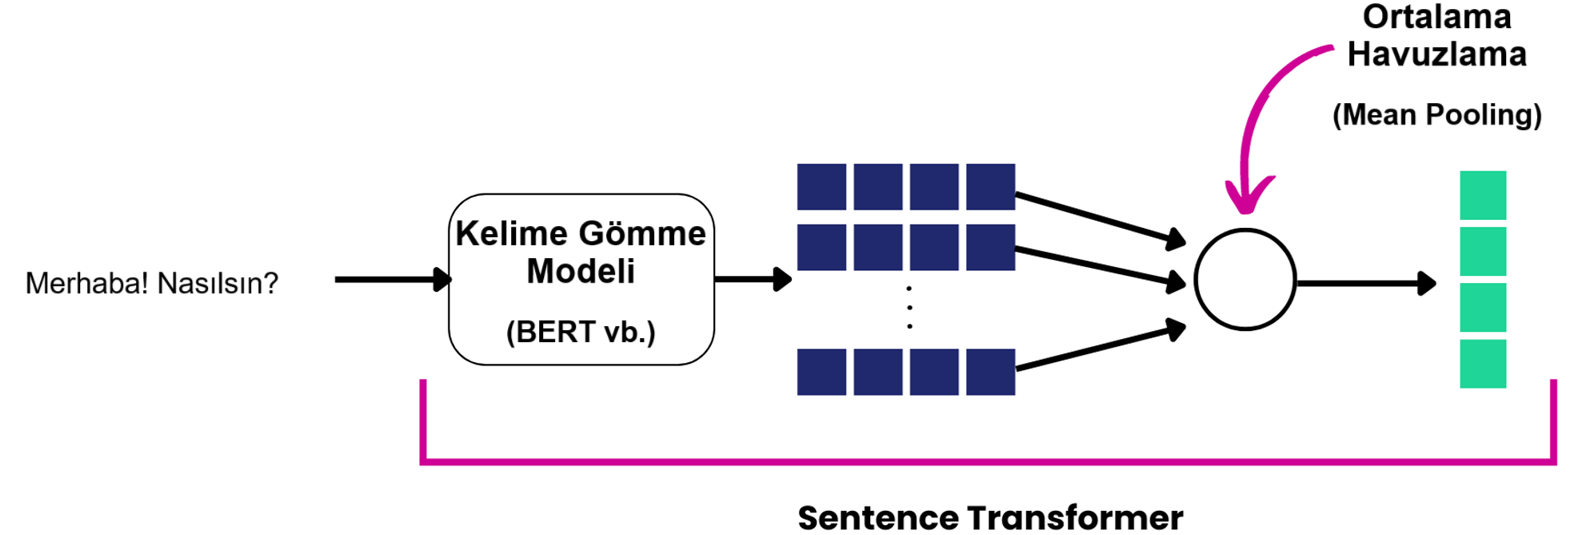


### 🎯 RAG Sistemi Açısından Embedding'in Faydası

| Faydası | Açıklama |
|--------|----------|
| 🔍 Semantik Eşleşme / Anlamsal Arama  | Sorguya en yakın anlamdaki belge parçaları bulunabilir |
| ⚡ Hızlı Erişim | Vektör veritabanları, benzerliği milisaniyeler içinde hesaplar |
| 🧠 Daha Doğru Yanıt | LLM, iç bilgisini değil, dış bilgiyi kullanarak daha isabetli sonuç verir |
| 🔗 Güncellenebilirlik | Yeni belgeler eklenerek sistem güncel tutulabilir |


### 🔐 Özet

- Gömme (embedding), metni sayısal ve anlamsal bir temsile dönüştürür.
- Bu temsiller, semantik benzerliklere göre karşılaştırılabilir hale gelir.
- RAG sistemlerinde bu vektör temsiller, dış bilgiye erişim için temel mekanizmadır.
- `sentence_transformers` kütüphanesi, çok dilli destek ve yüksek doğrulukla bu işlemi sağlar.


### 🚀 Bir Sonraki Adım

Vektörleştirme tamamlandığında, bu vektörler artık `ChromaDB` gibi bir vektör veri tabanına aktarılabilir.  
Böylece, kullanıcıdan gelen sorulara uygun içerikler **anlam bazlı** olarak hızla bulunur ve LLM'e bağlam olarak verilir.



## 🧠 Vektör Veritabanına Giriş



Erişim Destekli Metin Üretimi (RAG) sistemlerinde, bilgiye hızlı ve doğru erişim sağlanabilmesi için **gömülmüş (embedding) metinlerin** özel olarak yapılandırılmış bir **vektör veritabanında (vector database)** saklanması gerekir.  
Bu veritabanı, metinleri **anlam temelli** (semantik) vektörler aracılığıyla karşılaştırır ve en benzer içeriklere hızlı erişim sağlar.

### 🧩 Metinlerin Gömme İşlemi (Embedding of Texts)

Her bir metin parçası, **anlamsal yapısını yansıtan sayısal bir vektöre** dönüştürülür.  
Bu vektörler, benzer anlamlara sahip metinlerin **vektör uzayında birbirine yakın** konumlanmasını sağlar.  
Sonuç olarak, bir kullanıcı sorgusu da vektöre dönüştürülerek **doğrudan anlam benzerliğiyle** sorgulanabilir.










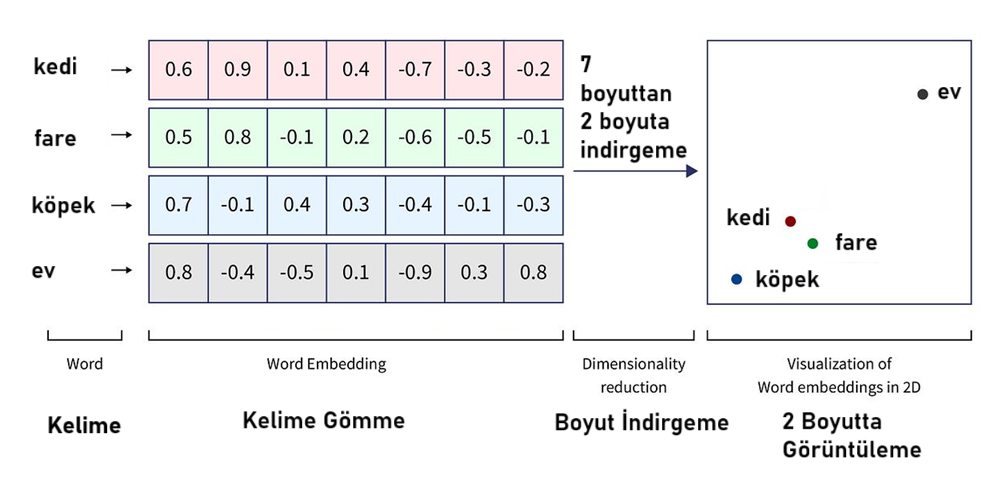

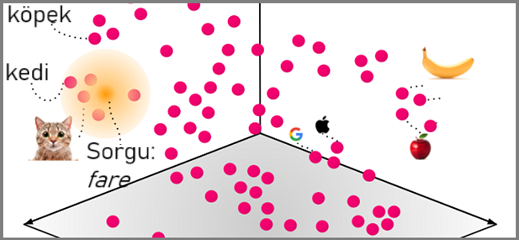

### 🗃️ Vektör Veritabanına Kayıt (Storing in the Vector Database)

Elde edilen embedding (gömme) vektörleri, aşağıdaki amaçlarla vektör veritabanına kaydedilir:

- 🔎 **Anlam temelli arama (semantic search)**
- ⚡ **Yüksek hızlı benzerlik sorguları**
- 🧩 **RAG sisteminde hatırlanacak bağlamın seçilmesi**



### 🔧 Bu Eğitimde Kullanılan Vektör Veritabanı: `ChromaDB`

Bu uygulamada **ChromaDB** adlı açık kaynak vektör veritabanı kullanılmaktadır.  
ChromaDB, hem güçlü hem de kullanıcı dostu bir araç olup aşağıdaki avantajlara sahiptir:

- ✅ **Metin + embedding vektörlerini birlikte saklayabilir.**

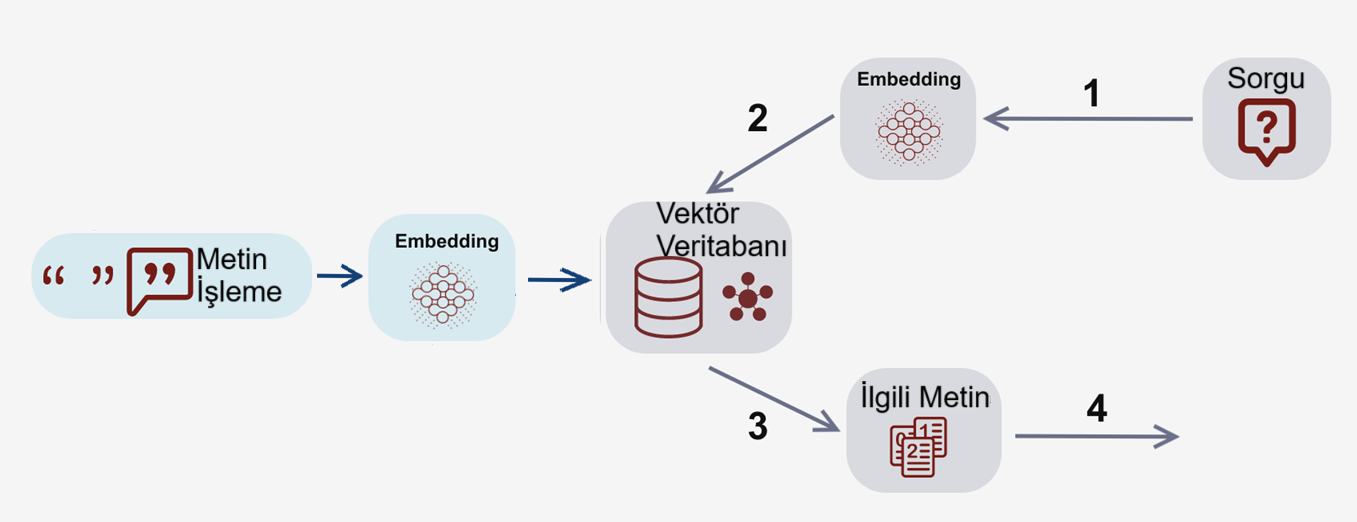

- ✅ **Yalnızca metin verisi verildiğinde, tanımlı bir gömme modeliyle (embedding function) otomatik olarak vektörleştirme yapabilir.**
- ✅ **Sorgu cümlelerini de aynı gömme fonksiyonuyla dönüştürerek semantik sorgulama gerçekleştirebilir.**
- ✅ **Kolay kurulum ve Python üzerinden basit API kullanımı** sağlar.

### 🛠️ Bu Uygulamada Nasıl Kullanıyoruz?

Bu eğitimde pratiklik ve sadelik açısından, ChromaDB’nin **otomatik gömme (automatic embedding)** özelliği kullanılacaktır.  
Yani:

- 💬 Elimizdeki metin parçaları doğrudan ChromaDB’ye verilecek
- 🔁 ChromaDB, önceden tanımlanmış embedding modelini (`distiluse-base-multilingual-cased-v1`) kullanarak bu metinleri otomatik olarak vektöre çevirecek
- 📥 Aynı işlem kullanıcıdan gelen sorgular için de geçerli olacak


### 🎯 ChromaDB ile birlikte şunları elde ediyoruz:

| Özellik                     | Açıklama |
|----------------------------|----------|
| Gömme (embedding)          | Anlamsal temsil ile vektörlere çevirme |
| Saklama (storage)          | Vektörleri belgeyle eşleştirerek saklama |
| Anlam temelli erişim       | Sorgulara en benzer içerikleri hızlıca getirme |
| Otomatik embedding         | Gömme işlemini ChromaDB’nin içinde otomatik yapma |


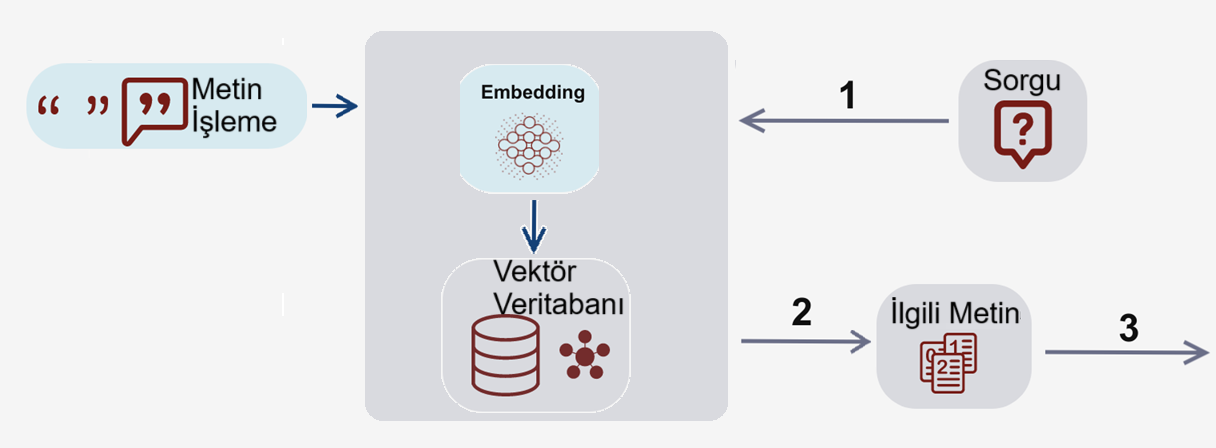

## 📐Vektör Veritabanını Hazırlama

Bu bölümde, **gömme (embedding) işlemi** sonucu elde edilen metin vektörlerini saklayacağımız bir **vektör veritabanı (vector database)** oluşturacağız. Bu işlem, RAG sistemlerinde bilgiye hızlı erişim sağlamak için kritik bir adımdır.


### 🧰 Kullanılan Araç: `ChromaDB`

Bu eğitimde, vektör veritabanı olarak **ChromaDB** kütüphanesi kullanılmaktadır.

> 🔧 **ChromaDB**, embedding vektörlerini ve bunlarla ilişkili metinleri disk üzerinde kalıcı (persistent) olarak saklayabilen, hızlı ve açık kaynaklı bir vektör veritabanıdır.

Aşağıdaki uygulamada:

- ✅ Kalıcı bir ChromaDB istemcisi
- ✅ Belirli bir embedding modeliyle çalışan bir koleksiyon
- ✅ Otomatik embedding desteği
- ✅ Metadata hazırlama altyapısı

hazır hale gelmiştir.



### UYGULAMA



#### 📦 Gerekli Kurulumlar
Öncelikle `chromadb` kütüphanesini yüklüyoruz:

In [ ]:
!pip install -q chromadb

In [ ]:
import chromadb
# Vektör veritabanı için dosya yolu belirle
vector_database_path = "./" # Mevcut dizini kullan

#### 🧠 Embedding Fonksiyonu Tanımlama
ChromaDB, istenirse metinleri vektöre dönüştürebilecek bir embedding fonksiyonunu (embedding function) kendisi çalıştırabilir.

Bu uygulamada sentence_transformers kütüphanesindeki modeli tanımlayarak embedding işlemini ChromaDB’ye devrediyoruz.

In [ ]:
from chromadb.utils import embedding_functions
# SentenceTransformer modelini kullanarak bir embedding fonksiyonu oluştur
# Bu fonksiyon, metin parçalarını vektörlere dönüştürmek için kullanılacak

# önce modeli seç
sentence_transformer_model="distiluse-base-multilingual-cased-v1"
# sonra fonksiyonu oluştur
embedding_function= embedding_functions.SentenceTransformerEmbeddingFunction(model_name=sentence_transformer_model)

#### 🗂️ ChromaDB İstemcisi ve Koleksiyon Oluşturma
Bir vektör veritabanı oluşturmak için PersistentClient sınıfı kullanılır. Bu sayede veriler disk üzerinde saklanır.  

**NOT:** Gömme fonksiyonunu Chroma İstemcisine sağladık. Bu nedenle, 128 token sınırına göre bölünmüş parçalar halinde metni sağladığımızda, ***gömme fonksiyonunu otomatik olarak kullanacaktır***!

In [ ]:
import chromadb

def create_chroma_client(vector_database_path, collection_name, embedding_function):
  # Kalıcı (Persistent) bir ChromaDB istemcisi oluştur
  # Bu, vektör veritabanının diske kaydedilmesini ve oturumlar arasında kalıcı olmasını sağlar
  chroma_client = chromadb.PersistentClient(path=vector_database_path)

  # Belirtilen isimde bir koleksiyonun var olup olmadığını kontrol et
  try:
      chroma_collection = chroma_client.get_collection(collection_name)
      print(f"'{collection_name}' adlı koleksiyon zaten mevcut. Siliniyor...")
      # Eğer koleksiyon mevcutsa sil
      chroma_client.delete_collection(collection_name)
      print(f"'{collection_name}' adlı koleksiyon silindi.")
      # Silme işleminden sonra koleksiyonu yeniden oluştur
      chroma_collection = chroma_client.create_collection(collection_name, embedding_function=embedding_function)
      print(f"'{collection_name}' adlı koleksiyon yeniden oluşturuldu.")
  except:
      # Eğer koleksiyon mevcut değilse, doğrudan oluştur
      chroma_collection = chroma_client.create_collection(collection_name, embedding_function=embedding_function)
      print(f"'{collection_name}' adlı yeni koleksiyon oluşturuldu.")


  # Oluşturulan istemciyi ve koleksiyonu döndür
  return chroma_client, chroma_collection

#### 🔍 Kontrol: Koleksiyon Durumu

Gerekli parametre değerlerini vererek ChromaDB veritabanınında kolleksiyonu oluştur

In [ ]:
collection_name= "Yonergeler"
chroma_client, chroma_collection = create_chroma_client(vector_database_path,
                                                        collection_name,
                                                        embedding_function)
print("📚Koleksiyon Oluşturuldu")
print(f"\tChromadb de bulunan koleksiyonlar: {chroma_client.list_collections()}")
print(f"\tToplam belge saysı: {chroma_collection.count()}")

#### 🏷️ Üst Veriyi Hazırlama

Parçanın ait olduğu dosyanın ismi, parçanın dosya içindeki sırası, koleksiyona ait detay bilgi, vb.  üst veri olarak vermemiz faydalı olacaktır. Aşağıdaki fonksiyon bir belgeye ait tüm parçalara verilen üst veriyi (meta data) eklemektedir.

In [ ]:
def add_meta_data(text_chunksinTokens, title, category, initial_id):
  ids = [str(i+initial_id) for i in range(len(text_chunksinTokens))]
  metadata = {
      'document': title,
      'category': category
  }
  metadatas = [ metadata for i in range(len(text_chunksinTokens))]
  return ids, metadatas

Hatırlarsanız daha önceden örnek metinler hazırlamıştık

In [ ]:
for i in range(len(sample_chunks)):
  print(f"Chunk {i}: {sample_chunks[i]})")

Gerekli diğer parametreler için örnek üst veri hazırlayalım:

In [ ]:
sample_category="Egitim Yonergeleri"
sample_file_name = "LisansYonergesi.pdf"

Şimdi hazırladığımız fonsksiyonu kullanarak örnek veri için üst veriyi hazırlayalım:  

In [ ]:
ids,metadatas = add_meta_data(sample_chunks,sample_file_name,sample_category, 0)
ids, metadatas

## 💾Metin Parçalarını Vektör Veritabanında Saklama



Bir metni doğrudan ChromaDB'ye eklediğimizde, bu metinler sadece düz yazı olarak değil; aynı zamanda **sayısal temsillerine (embedding vektörlerine)** dönüştürülerek saklanır. Bu dönüşüm, modelin metnin anlamını daha sonra hızlıca hatırlayabilmesi için gereklidir.

Bu işlemi gerçekleştirebilmek için, ChromaDB koleksiyonu oluşturulurken bir **embedding function** (gömme fonksiyonu) tanımlanır. Bu fonksiyon genellikle bir **SentenceTransformer** modeli ya da `huggingface` uyumlu başka bir gömme modeli olabilir.

Önceki adımda, `embedding_functions.SentenceTransformerEmbeddingFunction` sınıfı ile bu modeli tanımladık ve koleksiyonu şu şekilde oluşturduk:

```python
sentence_transformer_model="distiluse-base-multilingual-cased-v1"
embedding_function= embedding_functions.
                    SentenceTransformerEmbeddingFunction
                    (model_name=sentence_transformer_model)

chroma_collection = chroma_client.create_collection
                    (collection_name,
                    embedding_function=embedding_function)
      
````

Bu sayede `chroma_collection.add()` fonksiyonu kullanıldığında, eklediğimiz metinler otomatik olarak embedding modelinden geçirilir ve her bir parçaya karşılık gelen vektör, Chroma veritabanına eklenir.

Yani:

* ✔️ **Embedding işlemi manuel yapılmaz.**
* ⚙️ Chroma, `embedding_function` ile her metni otomatik olarak vektöre dönüştürür.
* 📦 Bu vektörler daha sonra benzerlik karşılaştırmalarında (semantic search) kullanılır.

Aşağıdaki hücrede, oluşturulan metin parçaları `documents`, `metadatas` ve `ids` şeklinde tanımlanarak koleksiyona eklenmektedir.


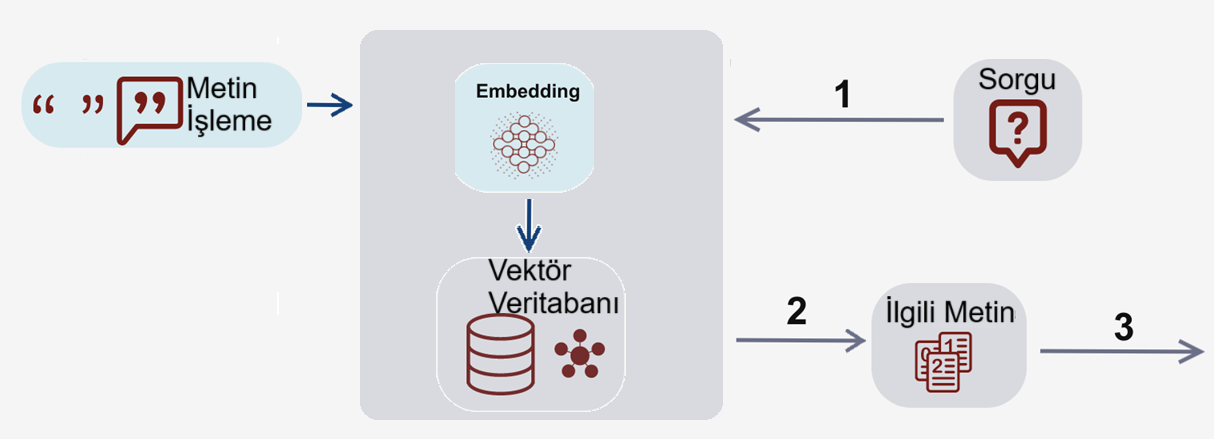

 Şimdi metin parçalarını ve onlara ait üst veriyi ChromaDB ye ekleyecek fonksiyonu yazabiliriz:

In [ ]:
def add_document_to_collection(ids, metadatas, text_chunksinTokens, chroma_collection):
  # Ekleme işleminden önceki koleksiyon boyutunu yazdır
  print("Ekleme işleminden önceki koleksiyon boyutu: ", chroma_collection.count())
  # Belgeleri, metadata ve ID'leri belirterek ChromaDB koleksiyonuna ekle
  chroma_collection.add(ids=ids, metadatas= metadatas, documents=text_chunksinTokens)
  # Ekleme işleminden sonraki koleksiyon boyutunu yazdır
  print("Ekleme işleminden sonraki koleksiyon boyutu: ", chroma_collection.count())
  # Güncellenmiş koleksiyon nesnesini döndür
  return chroma_collection

In [ ]:
chroma_collection = add_document_to_collection(ids, metadatas, sample_chunks, chroma_collection)

## 🔍Vektör Veritabanından Metin Parçalarına Erişim


Bu bölümde, daha önce vektör veritabanına (ChromaDB) eklenen metin parçalarına nasıl erişileceğini öğreniyoruz. Erişim, iki farklı yöntemle mümkündür:

1. **İndeks Temelli Erişim:**  
   Her metin parçası, veritabanına eklenirken bir kimlik (ID) ile birlikte kaydedilir. Bu yöntemde, belirli bir parçaya doğrudan ID'si aracılığıyla ulaşılır. Bu yöntem, özellikle parçaların yerini ve numarasını bildiğimiz durumlarda hızlıca bilgiye ulaşmak için idealdir.

2. **Anlam Temelli Erişim (Semantic Retrieval):**  
   Bu yöntemde kullanıcıdan gelen doğal dildeki bir sorgu, tıpkı metin parçalarında olduğu gibi embedding'e dönüştürülür. Ardından bu sorgu vektörü, veritabanındaki diğer vektörlerle karşılaştırılarak en anlamlı eşleşmeler bulunur. Böylece kullanıcı, doğrudan bir ID bilmeden de doğru bilgiye ulaşabilir.

Bu iki yöntem birlikte kullanıldığında, hem kesin hem de esnek bir erişim imkânı sağlar. Özellikle RAG (Retrieval-Augmented Generation) sistemlerinde, bağlama uygun bilgi seçimi için anlam temelli erişim büyük önem taşır.


### Indeks Temelli Erişim
Koleksiyona eklediğimiz belgelere indeks numarası üzerinden erişebiliriz:


In [ ]:
chroma_collection.get(['3'])

### 🔍 Anlam Temelli Erişim (Semantic Retrieval)

Bu aşamada, **kullanıcının sorgusunu** bilgi tabanımızda daha önce gömme (embedding) işlemiyle vektörleştirilmiş metin parçalarıyla **anlamsal olarak eşleştiriyoruz**.




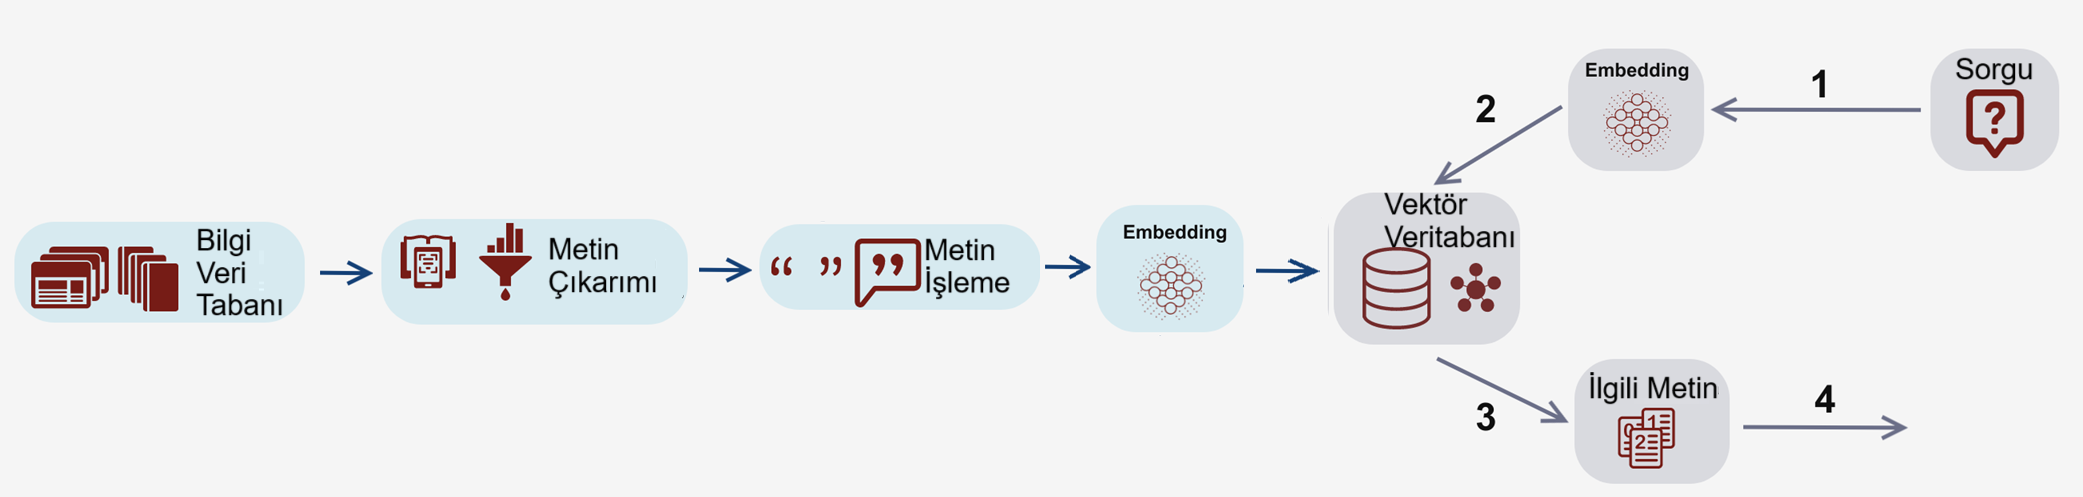

#### 🧭 Süreç Nasıl İşliyor?

1. **Kullanıcı Sorgusu (Query):**  
   Kullanıcı, sistemle doğal dilde bir soru veya komut (örneğin: "RAG nasıl çalışır?") gönderir.

2. **Sorgunun Gömme Vektörüne Dönüştürülmesi:**  
   Bu sorgu, tıpkı daha önce metin parçalarını vektörleştirdiğimiz gibi bir **gömme (embedding) modeli** ile sayısal bir vektöre dönüştürülür.






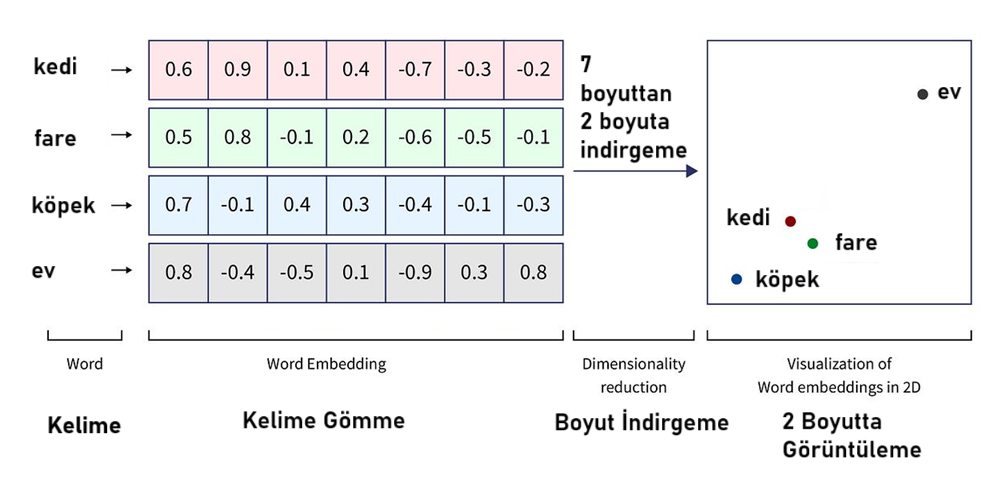

3. **Anlamsal Karşılaştırma (Semantic Matching):**  
   Sorgu vektörü, vektör veritabanında yer alan tüm metin parçalarının vektörleriyle karşılaştırılır.

4. **Benzerlik (Similarity) Ölçümü:**  
   Karşılaştırma, genellikle **kosinüs benzerliği (cosine similarity)** veya **vektörler arası mesafe (distance)** kullanılarak yapılır.  
   Bu ölçüm, sorguya en anlamca yakın metinleri belirler.

5. **En Yakın K Parçayı Seçme  (Top-K Retrieval):**  
   Elde edilen benzerlik puanlarına göre vektör veritabanı, **en alakalı K adet metin parçasını** sıralar ve getirir.  
   Bu parçalar daha sonra LLM’e bağlam olarak verilir.

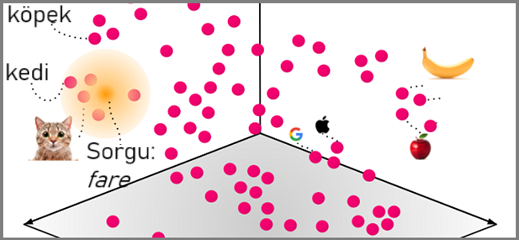


#### 💡 Klasik Anahtar Kelime Aramasından Farklı?

- Anahtar kelime tabanlı sistemler sadece kelime eşleşmesine bakar.  
  → Örneğin "yapay zeka" ve "AI" sistem tarafından farklı olarak değerlendirilir.

- Anlam temelli erişim ise bağlama bakar.  
  → "LLM nedir?" ve "Büyük dil modeli hakkında bilgi verir misin?" gibi farklı şekillerde sorulmuş ifadeleri aynı veya benzer içerikle eşleştirebilir.


| Aşama | Açıklama |
|-------|----------|
| Sorgu | Kullanıcının doğal dilde yazdığı metin |
| Embedding | Sorgunun sayısal, anlamsal vektöre dönüştürülmesi |
| Vektör Karşılaştırma | Gömme vektörleri arasında benzerlik ölçümü |
| Top-K Retrieval | En benzer K parçanın seçilmesi |
| Sonuç | En alakalı bilgi parçalarının LLM’e bağlam olarak verilmesi |

Bu süreç, **RAG mimarisinin temel yapı taşı** olan "dış bilgiye dayalı üretim" için vazgeçilmezdir.  
Doğru gömme → doğru karşılaştırma → doğru bağlam → güvenilir yanıt zincirini kurar.



## ❓Vektör Veritabanını Sorgulama

Bu bölümde, kullanıcıdan gelen bir doğal dil sorgusunun vektöre dönüştürülüp daha önce oluşturulan vektör veritabanı ile nasıl karşılaştırıldığını göreceğiz. Amaç, anlamca en benzer metin parçalarını bulmaktır.

ChromaDB, bu karşılaştırmayı embedding uzayında yapar. Kullanıcı sorgusu bir gömme (embedding) fonksiyonu yardımıyla vektör haline getirilir ve veritabanındaki tüm metinlerle semantik benzerlik açısından karşılaştırılır.

- 🔹 En benzer parçalar belirli bir `distance` ölçütüne göre sıralanır.  
- 🔹 Bu işlem sayesinde LLM’e bağlam olarak verilecek doğru bilgi parçaları otomatik seçilir.  
- 🔹 Böylece, RAG sistemlerinin temel adımlarından biri olan **anlam temelli bilgi geri çağırma** başarıyla gerçekleştirilmiş olur.

Aşağıdaki uygulamada, ChromaDB'nin `query()` yöntemi kullanılarak sorguya en yakın 3 metin parçası elde edilmektedir.


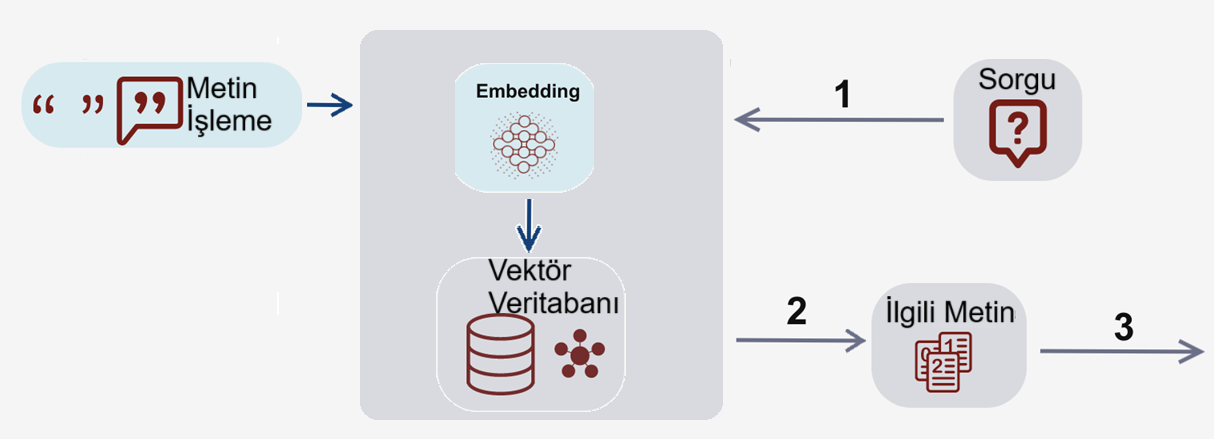

In [ ]:
sample_queries=[
    "Muafiyet hakkından vazgeçmek isteyen bir öğrenci nasıl bir başvuru yapmalıdır?",
    "Muafiyetten feragat eden öğrenci tekrar başvuru yapabilir mi?",
    "Ders grupları ve kontenjanlar kim tarafından belirlenir?",
    "Muafiyet başvurusu nasıl yapılır?", # NOTE: Chunk'larda feragat süreci anlatılıyor, başvuru süreci değil.
    "Öğrencinin muafiyet hakkı kaç kere kullanılabilir?" # NOTE: Tekrar başvuru yasağı var ama kullanım sayısı hakkında bilgi yok.
]

In [ ]:
# Sorgu numarasını belirle (hangi örnek sorgunun kullanılacağını seç)
query_no=0
# Seçilen sorguyu yazdır
print(f"Sorgu: {sample_queries[query_no]}")
# Chroma koleksiyonunu sorgula
chroma_collection.query(
    query_texts=sample_queries[query_no], # Sorgu metnini belirt
    n_results=3,  # Kaç sonuç (en yakın k parça) döneceğini belirt
)

### 📘 Bu Ne Anlama Geliyor?

Bu komut, `"Muafiyet hakkından vazgeçmek isteyen bir öğrenci nasıl bir başvuru yapmalıdır?"` ifadesine **anlamsal olarak en yakın metin parçalarını** bulmak için ChromaDB'yi kullanır.

Notebook’ta daha önce metin parçaları (chunks) vektörlere (embedding) dönüştürülerek bir Chroma koleksiyonuna eklenmişti. Bu sorgu da, verilen ifadenin embedding karşılığını hesaplayarak koleksiyondaki vektörlerle **anlamsal benzerliğe** göre karşılaştırır ve en yakın eşleşmeleri döndürür.


#### 🔍 Çıktının Öğeleri

- 🆔 `ids`
 ```
 'ids': \[\['1', '0', '3']]
 ```
 - Bunlar, en benzer bulunan metin parçalarının kimlik numaralarıdır.
 - `"1"` ve `"0"` numaralı parçalar doğrudan "muafiyet" konusunu içermekte ve yüksek benzerlik göstermektedir.
 - `"3"` numaralı parça ise doğrudan ilişkili olmasa da semantik olarak belirli bir benzerlik içeriyor olabilir (örneğin, resmi süreçleri anlatması gibi).



- 📄 `documents`
 ```
'documents': [
'Muafiyetten feragat eden öğrenci, aynı ders / dersler için bir daha muafiyet veya intibak başvurusunda bulunamaz.',
'Öğrenci, muafiyet sonuçları ilan edilmesinden itibaren en geç üç ( 3 ) iş günü içerisinde yazılı dilekçeyle ilgili fakülteye başvurarak muafiyetten feragat edebilir.',
'Senato tarafından uygun görülmesi halinde lisans programlarındaki bazı dersler uzaktan öğretim yoluyla verilebilir.'
]
```
 - Bu metinler, sorgu ifadesine anlamca en yakın bulunan içeriklerdir.
 - Özellikle 2. metin, doğrudan sorunun cevabını içermektedir: yazılı dilekçeyle başvuru yapılacağı belirtiliyor.
 - İlk metin, feragat sonrası kısıtlamayı açıklarken; üçüncü metin alakasız gibi görünse de vektör düzeyinde düşük de olsa bir benzerlik taşımaktadır.


- 🧾 `metadatas`
 ```
'metadatas': [
{'document': 'LisansYonergesi.pdf', 'category': 'Egitim Yonergeleri'},
{'document': 'LisansYonergesi.pdf', 'category': 'Egitim Yonergeleri'},
{'document': 'LisansYonergesi.pdf', 'category': 'Egitim Yonergeleri'}
]
```
 - Her bir metin parçası `"LisansYonergesi.pdf"` adlı belgeye ve `"Egitim Yonergeleri"` kategorisine aittir.
 - Bu bilgi, geri getirilen parçaların hangi kaynaktan geldiğini ve hangi başlık altında sınıflandığını gösterir.


-  `distances`
 ```
 'distances': [0.9477, 1.1310, 1.3730]
 ```
 - Bu sayılar, sorgu ifadesi ile her dönen metin parçası arasındaki **anlamsal uzaklığı** gösterir.
 - Sayı **küçüldükçe**, benzerlik **artar**.
 - Örneğin:
   - `0.9477`: En yüksek benzerliği gösterir (id: '1')
   - `1.1310`: Orta düzey benzerlik (id: '0')
   - `1.3730`: Düşük benzerlik (id: '3')





| Metin Parçası                                                              | Uzaklık (distance) | Anlamsal Benzerlik    |
| -------------------------------------------------------------------------- | ------------------ | --------------------- |
| Muafiyetten feragat eden öğrenci tekrar başvuru yapamaz.                   | 0.9477             | Yüksek benzerlik      |
| Öğrenci, muafiyet sonuçlarından sonra yazılı dilekçe ile feragat edebilir. | 1.1310             | Orta-yüksek benzerlik |
| Lisans dersleri uzaktan öğretim yoluyla da verilebilir (Senato onayıyla).  | 1.3730             | Düşük benzerlik       |


#### ✅ Sonuç

Bu çıktı, `"Muafiyet hakkından vazgeçmek isteyen bir öğrenci nasıl bir başvuru yapmalıdır?"` sorgusuna anlamca en yakın metin parçalarının ChromaDB tarafından başarıyla getirildiğini gösteriyor.

İkinci metin (id: '0') doğrudan sorunun cevabını verirken, ilk metin (id: '1') sürecin sonucunu, üçüncü metin (id: '3') ise sadece bağlamsal uzaklıktan ötürü eklenmiş olabilir.

Bu tür çıktılar, **RAG (Retrieval-Augmented Generation)** sistemlerinde büyük dil modellerine (LLM) bağlam olarak sunularak daha doğru ve anlamlı yanıtlar elde edilmesini sağlar.

  
💡 Not: Chroma `distance` değeri, genellikle **L2 (Euclidean)** uzaklığı kullanır. Küçük değerler, daha yüksek benzerlik anlamına gelir. Eğer cosine similarity kullanılsaydı, bu değerler [0, 1] arasında olurdu ve büyük olan daha benzer sayılırdı.

### **EV ÖDEVİ:**
Aşağıdaki sorgu sonucunu açıklayınız ve yorumlayınız.

In [ ]:
query_no=4
print(f"Sorgu: {sample_queries[query_no]}")
chroma_collection.query(
    query_texts=sample_queries[query_no],
    n_results=3,  # Specify the number of results (top k)

)

### **EV ÖDEVİ:**
Diğer sorguları çalıştırınız ve sonuçları açıklayınız ve yorumlayınız.

## 🔗Tüm İş Akışının Kodlanması

Şimdiye kadar yaptığımız tüm adımlardaki kodlamaları bir araya getirip bir döngü içersinde Bilgi Tabanındaki tüm dosyları parçalayıp Vektör  Veritabanına gömeceğiz ve sorgulayacağız

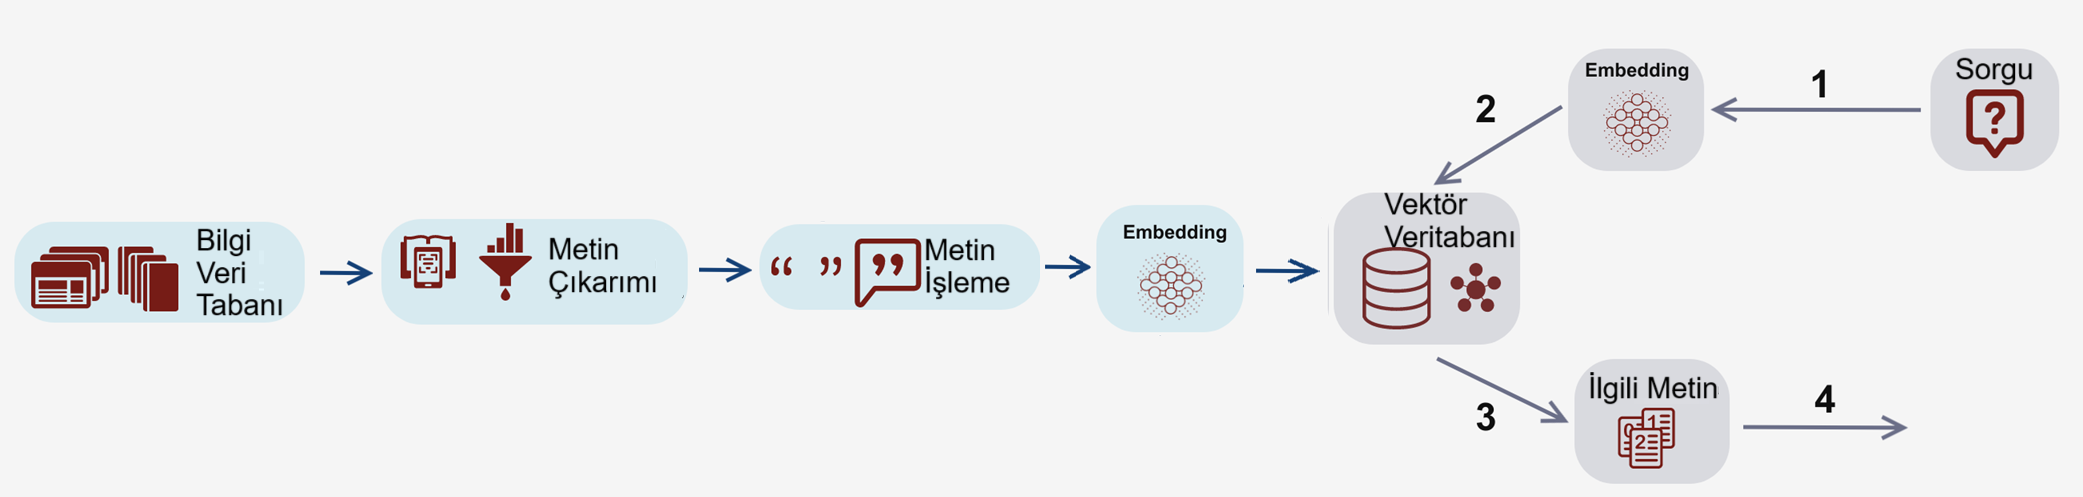

### Bilgi Tabanı (Knowledge Base) Oluştur

In [ ]:
# @title Örnek Belgeleri İndir
import requests
from urllib.parse import quote

# GitHub repository bilgileri
owner = "kmkarakaya"
repo = "btk_rag_bot_egitimi"
folder_path = "Örnek Bilgi Tabanı"

# API endpoint
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{quote(folder_path)}"

print("GitHub API'ye bağlanılıyor...")
try:
    response = requests.get(api_url)
    response.raise_for_status()

    files = response.json()
    pdf_files = [f for f in files if f['name'].lower().endswith('.pdf')]

    print(f"{len(pdf_files)} PDF dosyası bulundu:")

    downloaded_files = []

    for file in pdf_files:
        print(f"\nİndiriliyor: {file['name']}")

        try:
            file_response = requests.get(file['download_url'])
            file_response.raise_for_status()

            file_path = f"./{file['name']}"

            with open(file_path, 'wb') as f:
                f.write(file_response.content)

            file_size = len(file_response.content)
            print(f"✓ {file['name']} indirildi ({file_size:,} bytes)")
            print(f"  Konum: {file_path}")
            downloaded_files.append(file_path)

        except Exception as e:
            print(f"✗ {file['name']} indirilemedi: {e}")

    print(f"\n🎉 Toplam {len(downloaded_files)} PDF dosyası indirildi!")
    print("\nİndirilen dosyalar:")
    for file_path in downloaded_files:
        print(f"📄 {file_path}")

except Exception as e:
    print(f"API hatası: {e}")
    import traceback
    traceback.print_exc()

### PDF Belgelerini Yükle

In [ ]:
import os
def create_knowledge_base():
  # İndirilen dosya yollarını tutacak boş bir liste oluşturun
  downloaded_files = []

  # Mevcut dizindeki tüm dosya ve klasörleri listele
  for item in os.listdir('.'):
      # Eğer öğe bir dosyaysa ve '.pdf' ile bitiyorsa
      if os.path.isfile(item) and item.lower().endswith('.pdf'):
          # Dosya yolunu downloaded_files listesine ekle
          downloaded_files.append(item)

  # Bulunan PDF dosyalarını yazdır
  print("Yerel dizinde bulunan PDF dosyaları:")
  for file_path in downloaded_files:
      print(f"📄 {file_path}")

  print(f"\nToplam {len(downloaded_files)} PDF dosyası bulundu.")
  return downloaded_files

### Belgelerden Metin Çıkarımı (Text Extraction):

In [ ]:
%pip install -q PyPDF2
import PyPDF2

In [ ]:
def convert_PDF_Text(pdf_path):
  try:
    # Belirtilen PDF dosyasını okumak için PdfReader nesnesi oluştur
    reader = PyPDF2.PdfReader(pdf_path)
    # Her sayfadan metni çıkar ve baş/son boşlukları temizle
    pdf_pages = [p.extract_text().strip() for p in reader.pages]
    # Boş metin dizilerini filtrele
    pdf_pages = [text for text in pdf_pages if text]
    # Belge adını ve işlenen sayfa sayısını yazdır
    print("Belge: ", pdf_path,"\nSayfa Sayısı: ", len(pdf_pages))
    # Metin sayfalarının listesini döndür
    return pdf_pages
  except Exception as e:
    print(f"Hata oluştu: {pdf_path} dosyası işlenemedi. Hata: {e}")
    return [] # Hata durumunda boş liste döndür

### Metin İşleme (Chunking)

In [ ]:
# Langchain kütüphanesini yükle (eğer yüklü değilse)
%pip install langchain --quiet
import langchain

# Metinleri parçalara ayırmak için gerekli sınıfları içe aktar
from langchain.text_splitter import RecursiveCharacterTextSplitter, SentenceTransformersTokenTextSplitter

In [ ]:
def convert_Page_ChunkinChar(pdf_texts, chunk_size = 1500, chunk_overlap=200 ):
  # Karakter tabanlı metin ayırıcı nesnesi oluştur
  character_splitter = RecursiveCharacterTextSplitter(
      # Ayırıcı karakterleri tanımla
      separators=["\n\n", "\n", ". ", " ", ""],
      # Her parçanın maksimum karakter boyutunu belirle
      chunk_size=chunk_size,
      # Parçalar arasındaki çakışma miktarını belirle
      chunk_overlap=chunk_overlap
  )
  # PDF metinlerini belirtilen ayırıcılar ve boyutlarla parçalara ayır
  character_split_texts = character_splitter.split_text('\n\n'.join(pdf_texts))
  # Toplam parça sayısını yazdır
  print(f"\nToplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = {chunk_size}): \
        {len(character_split_texts)}")
  # Oluşturulan metin parçalarının listesini döndür
  return character_split_texts

In [ ]:
# sentence_transformers kütüphanesini yükle (eğer yüklü değillerse)
# sentence_transformers: Metinleri vektörlere dönüştürmek için kullanılır (embedding).
%pip install sentence_transformers --quiet

In [ ]:
# Metinleri token bazlı parçalara ayırmak için gerekli sınıfı içe aktar
from langchain.text_splitter import SentenceTransformersTokenTextSplitter

# Kullanılacak Sentence Transformer modelinin adını tanımla
# Bu model, metin parçalarını tokenlara ayırmak ve embedding işlemi için kullanılacak.
sentence_transformer_model="distiluse-base-multilingual-cased-v1"

In [ ]:
# Metinleri token bazlı parçalara ayıran yardımcı fonksiyon
def convert_Chunk_Token(text_chunksinChar,sentence_transformer_model, chunk_overlap=10,tokens_per_chunk=128 ):
  # SentenceTransformersTokenTextSplitter nesnesi oluşturuluyor
  token_splitter = SentenceTransformersTokenTextSplitter(
      chunk_overlap=chunk_overlap, # Parçalar arası çakışma miktarı
      model_name=sentence_transformer_model, # Kullanılacak tokenizer modelinin adı
      tokens_per_chunk=tokens_per_chunk) # Her bir parçadaki maksimum token sayısı

  # Tokenlara ayrılmış metin parçalarını tutacak boş liste
  text_chunksinTokens = []
  # Karakter bazlı parçalar üzerinde döngü
  for text in text_chunksinChar:
      # Her bir karakter bazlı parçayı tokenlara ayır ve listeye ekle
      text_chunksinTokens += token_splitter.split_text(text)
  # Bilgilendirme mesajı yazdır
  print(f"""\nBelge {tokens_per_chunk} token'lık parçalara bölündüğünde,
  ve çakışma token sayısı {chunk_overlap} olduğunda
  toplam parça sayısı: {len(text_chunksinTokens)}""")
  # Tokenlara ayrılmış metin parçaları listesini döndür
  return text_chunksinTokens

### Vektör Veritabanı Hazırla

In [ ]:
!pip install -q chromadb

In [ ]:
import chromadb
# Vektör veritabanı için dosya yolu belirle
vector_database_path = "./" # Mevcut dizini kullan

In [ ]:
from chromadb.utils import embedding_functions
# SentenceTransformer modelini kullanarak bir embedding fonksiyonu oluştur
# Bu fonksiyon, metin parçalarını vektörlere dönüştürmek için kullanılacak

# önce embedding modelini seç
sentence_transformer_model="distiluse-base-multilingual-cased-v1"
# sonra fonksiyonu oluştur
embedding_function= embedding_functions.SentenceTransformerEmbeddingFunction(model_name=sentence_transformer_model)

In [ ]:
def create_chroma_client(vector_database_path, collection_name, embedding_function):
  # Kalıcı (Persistent) bir ChromaDB istemcisi oluştur
  # Bu, vektör veritabanının diske kaydedilmesini ve oturumlar arasında kalıcı olmasını sağlar
  chroma_client = chromadb.PersistentClient(path=vector_database_path)

  # Belirtilen isimde bir koleksiyonun var olup olmadığını kontrol et
  try:
      chroma_collection = chroma_client.get_collection(collection_name)
      print(f"'{collection_name}' adlı koleksiyon zaten mevcut. Siliniyor...")
      # Eğer koleksiyon mevcutsa sil
      chroma_client.delete_collection(collection_name)
      print(f"'{collection_name}' adlı koleksiyon silindi.")
      # Silme işleminden sonra koleksiyonu yeniden oluştur
      chroma_collection = chroma_client.create_collection(collection_name, embedding_function=embedding_function)
      print(f"'{collection_name}' adlı koleksiyon yeniden oluşturuldu.")
  except:
      # Eğer koleksiyon mevcut değilse, doğrudan oluştur
      chroma_collection = chroma_client.create_collection(collection_name, embedding_function=embedding_function)
      print(f"'{collection_name}' adlı yeni koleksiyon oluşturuldu.")


  # Oluşturulan istemciyi ve koleksiyonu döndür
  return chroma_client, chroma_collection

In [ ]:
def add_meta_data(text_chunksinTokens, title, category, initial_id):
  # Parçalar için benzersiz kimlikler (ID'ler) oluştur
  ids = [str(i+initial_id) for i in range(len(text_chunksinTokens))]
  # Parçalara eklenecek metadata (üst veri) sözlüğü oluştur
  metadata = {
      'document': title,  # Belge adı
      'category': category # Belge kategorisi
  }
  # Her parça için aynı metadata'yı içeren bir liste oluştur
  metadatas = [ metadata for i in range(len(text_chunksinTokens))]
  # Oluşturulan ID'ler ve metadata listelerini döndür
  return ids, metadatas

In [ ]:
def add_document_to_collection(ids, metadatas, text_chunksinTokens, chroma_collection):
  # Ekleme işleminden önceki koleksiyon boyutunu yazdır
  print("Ekleme işleminden önceki koleksiyon boyutu: ", chroma_collection.count())
  # Belgeleri, metadata ve ID'leri belirterek ChromaDB koleksiyonuna ekle
  chroma_collection.add(ids=ids, metadatas= metadatas, documents=text_chunksinTokens)
  # Ekleme işleminden sonraki koleksiyon boyutunu yazdır
  print("Ekleme işleminden sonraki koleksiyon boyutu: ", chroma_collection.count())
  # Güncellenmiş koleksiyon nesnesini döndür
  return chroma_collection

### İş Akışını Tasarla

In [ ]:
def load_multiple_pdfs_to_ChromaDB(collection_name,sentence_transformer_model):
  # Koleksiyon adını belirle
  collection_name= collection_name
  # Kategori adını belirle
  category= "Ogrenci Yonergeleri"
  # Kullanılacak Sentence Transformer modelini belirle
  sentence_transformer_model=sentence_transformer_model
  # Embedding fonksiyonunu oluştur
  embedding_function= embedding_functions.SentenceTransformerEmbeddingFunction(model_name=sentence_transformer_model)
  # ChromaDB istemcisi ve koleksiyonunu oluştur veya al
  chroma_client, chroma_collection = create_chroma_client(vector_database_path, collection_name, embedding_function)
  # Mevcut koleksiyonun boyutunu al (ID'leri başlatmak için)
  current_id = chroma_collection.count()
  # Bilgi tabanındaki dosya isimlerini al
  file_names = create_knowledge_base()
  # Her dosya için döngü
  for file_name in file_names:
    # Belge işleme başlangıç mesajı
    print(f"\n📖 {file_name}, {chroma_collection.name} koleksiyonuna eklenmek üzere işleniyor. Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}")
    print(f"\n📚 Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}")
    # Başlangıç ID'sini yazdır
    print(f"\tBaşlangıç ID: {current_id} ")
    # PDF metnini sayfa sayfa çıkar
    pdf_texts = convert_PDF_Text(file_name)
    # Metni karakter bazlı parçalara ayır
    text_chunksinChar = convert_Page_ChunkinChar(pdf_texts)
    # Karakter bazlı parçaları token bazlı parçalara ayır
    text_chunksinTokens = convert_Chunk_Token(text_chunksinChar,sentence_transformer_model)
    # Metadata ve ID'leri hazırla
    ids,metadatas = add_meta_data(text_chunksinTokens,file_name,category, current_id)
    # Sonraki belge için başlangıç ID'sini güncelle
    current_id = current_id + len(text_chunksinTokens)
    # Belgeleri ChromaDB koleksiyonuna ekle
    chroma_collection = add_document_to_collection(ids, metadatas, text_chunksinTokens, chroma_collection)
    # Belgenin eklendiğine dair mesaj ve güncel parça sayısını yazdır
    print(f"📖{file_name} koleksiyona eklendi. Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}\n")

  print(f"📚Koleksiyona belgeler yüklendi👍\n")
  print(f"📚Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}\n")
  # ChromaDB istemcisi ve koleksiyonunu döndür
  return  chroma_client, chroma_collection

### İş Akışını Çalıştır

In [ ]:
collection_name = "Yonergeler"

In [ ]:
chroma_client, chroma_collection= load_multiple_pdfs_to_ChromaDB(collection_name,sentence_transformer_model)

### Sorgulama yap

In [ ]:
sample_queries=[
    "Muafiyet hakkından vazgeçmek isteyen bir öğrenci nasıl bir başvuru yapmalıdır?",
    "Muafiyetten feragat eden öğrenci tekrar başvuru yapabilir mi?",
    "Lisans ders grupları ve kontenjanlar kim tarafından belirlenir?",
    "Muafiyet başvurusu nasıl yapılır?", # NOTE: Chunk'larda feragat süreci anlatılıyor, başvuru süreci değil.
    "Öğrencinin muafiyet hakkı kaç kere kullanılabilir?" # NOTE: Tekrar başvuru yasağı var ama kullanım sayısı hakkında bilgi yok.
]

In [ ]:
query_no=2
print(f"Sorgu: {sample_queries[query_no]}")
chroma_collection.query(
    query_texts=sample_queries[query_no],
    n_results=5,  # Specify the number of results (top k)
)

### Bu Bölümden Sonra Neler Öğreneceğiz?

Bu bölümde, RAG mimarisinin nasıl çalıştığını teorik ve pratik yönleriyle öğrendik. Artık temel parçaların ne olduğunu, nasıl etkileştiğini ve neden bu yaklaşımın LLM sistemlerini geliştirdiğini biliyoruz.

📌 Sonraki bölümde:

💡 Bunları öğrendikten sonra, LLM + ChromaDB ile tam işleyen bir erişim destekli sohbet botu sistemini uçtan uca kuracak seviyeye geleceğiz.

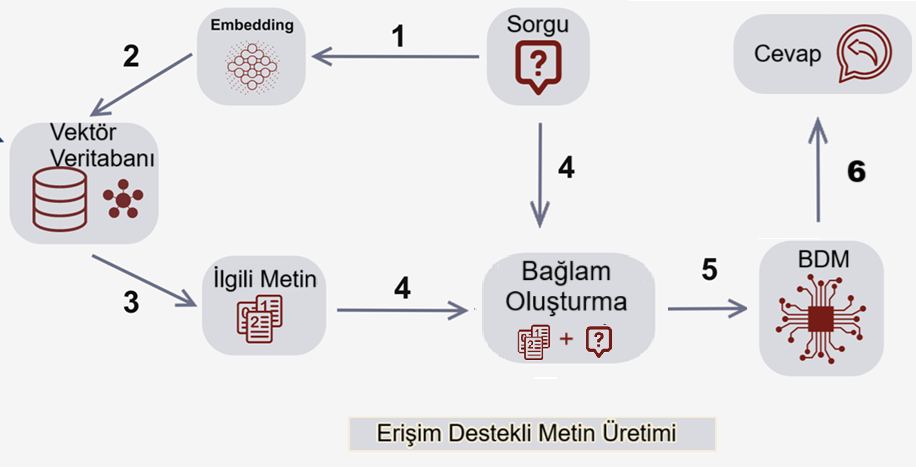

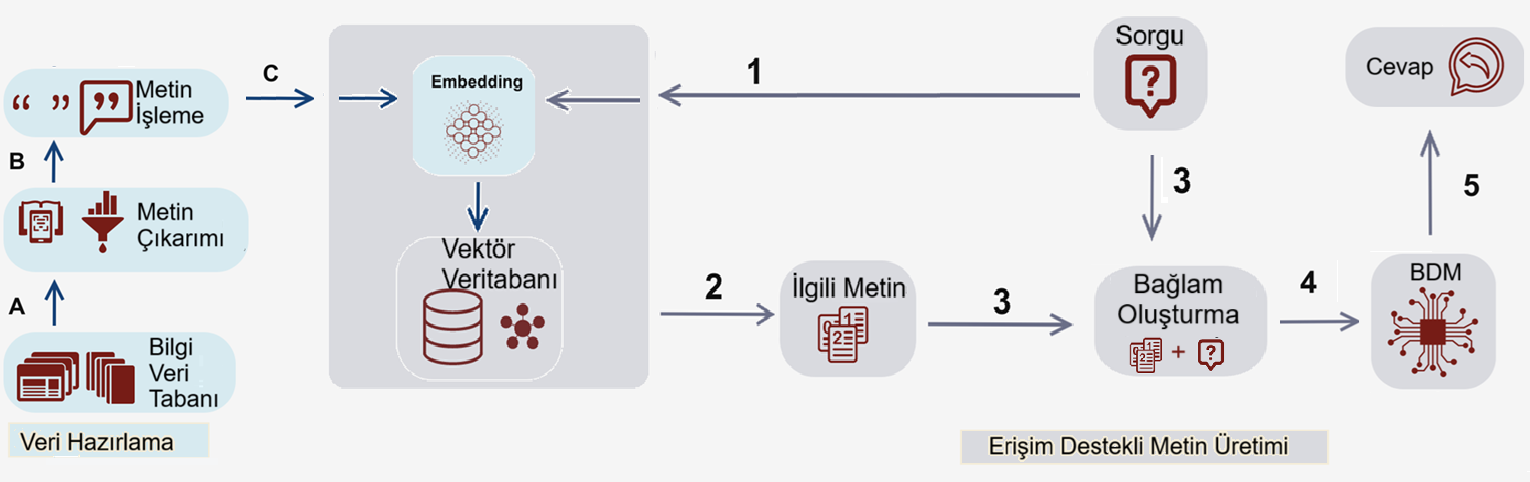
